# Project Work XAI

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux.")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp/tmux-1022/default,126489,1


## Environment management

In [3]:
from k_validation.K_fold import *
from models.neural_network import *
from utils.data_processing import *
from utils.pipeline import pipeline

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [4]:
X, y, feature_names = load_and_preprocess_data(dataset_path="../Data/MARSIS_historical_dataset.csv", orbit_path="../Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

### Experiment 1: batch_size = 32

=== Starting Experiment Pipeline: exp_1 ===
Created isolated environment at: experiments/exp_1_20260725_113507

--- Starting FOLD 0 ---


Early stopping at epoch 19
Train MSE: 7.860, Test MSE: 11.731, Train MAE: 2.142, Test MAE: 2.641

--- Starting FOLD 1 ---


Early stopping at epoch 13
Train MSE: 8.123, Test MSE: 10.165, Train MAE: 2.205, Test MAE: 2.516

--- Starting FOLD 2 ---


Early stopping at epoch 11
Train MSE: 8.554, Test MSE: 10.347, Train MAE: 2.278, Test MAE: 2.582

--- Starting FOLD 3 ---


Early stopping at epoch 11
Train MSE: 8.699, Test MSE: 11.953, Train MAE: 2.294, Test MAE: 2.703

--- Starting FOLD 4 ---


...

Early stopping at epoch 11
Train MSE: 8.283, Test MSE: 47.688, Train MAE: 2.242, Test MAE: 5.143

--- Starting FOLD 6 ---


Early stopping at epoch 21
Train MSE: 7.141, Test MSE: 40.175, Train MAE: 2.002, Test MAE: 4.739

--- Starting FOLD 7 ---


Early stopping at epoch 18
Train MSE: 7.432, Test MSE: 19.957, Train MAE: 2.069, Test MAE: 3.199

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 8.828, Test MSE: 12.524, Train MAE: 2.312, Test MAE: 2.854

--- Starting FOLD 9 ---


Early stopping at epoch 13
Train MSE: 7.932, Test MSE: 10.695, Train MAE: 2.176, Test MAE: 2.385

Execution 'exp_1' successfully completed in 12873.60s!
Generating Learning Curves...


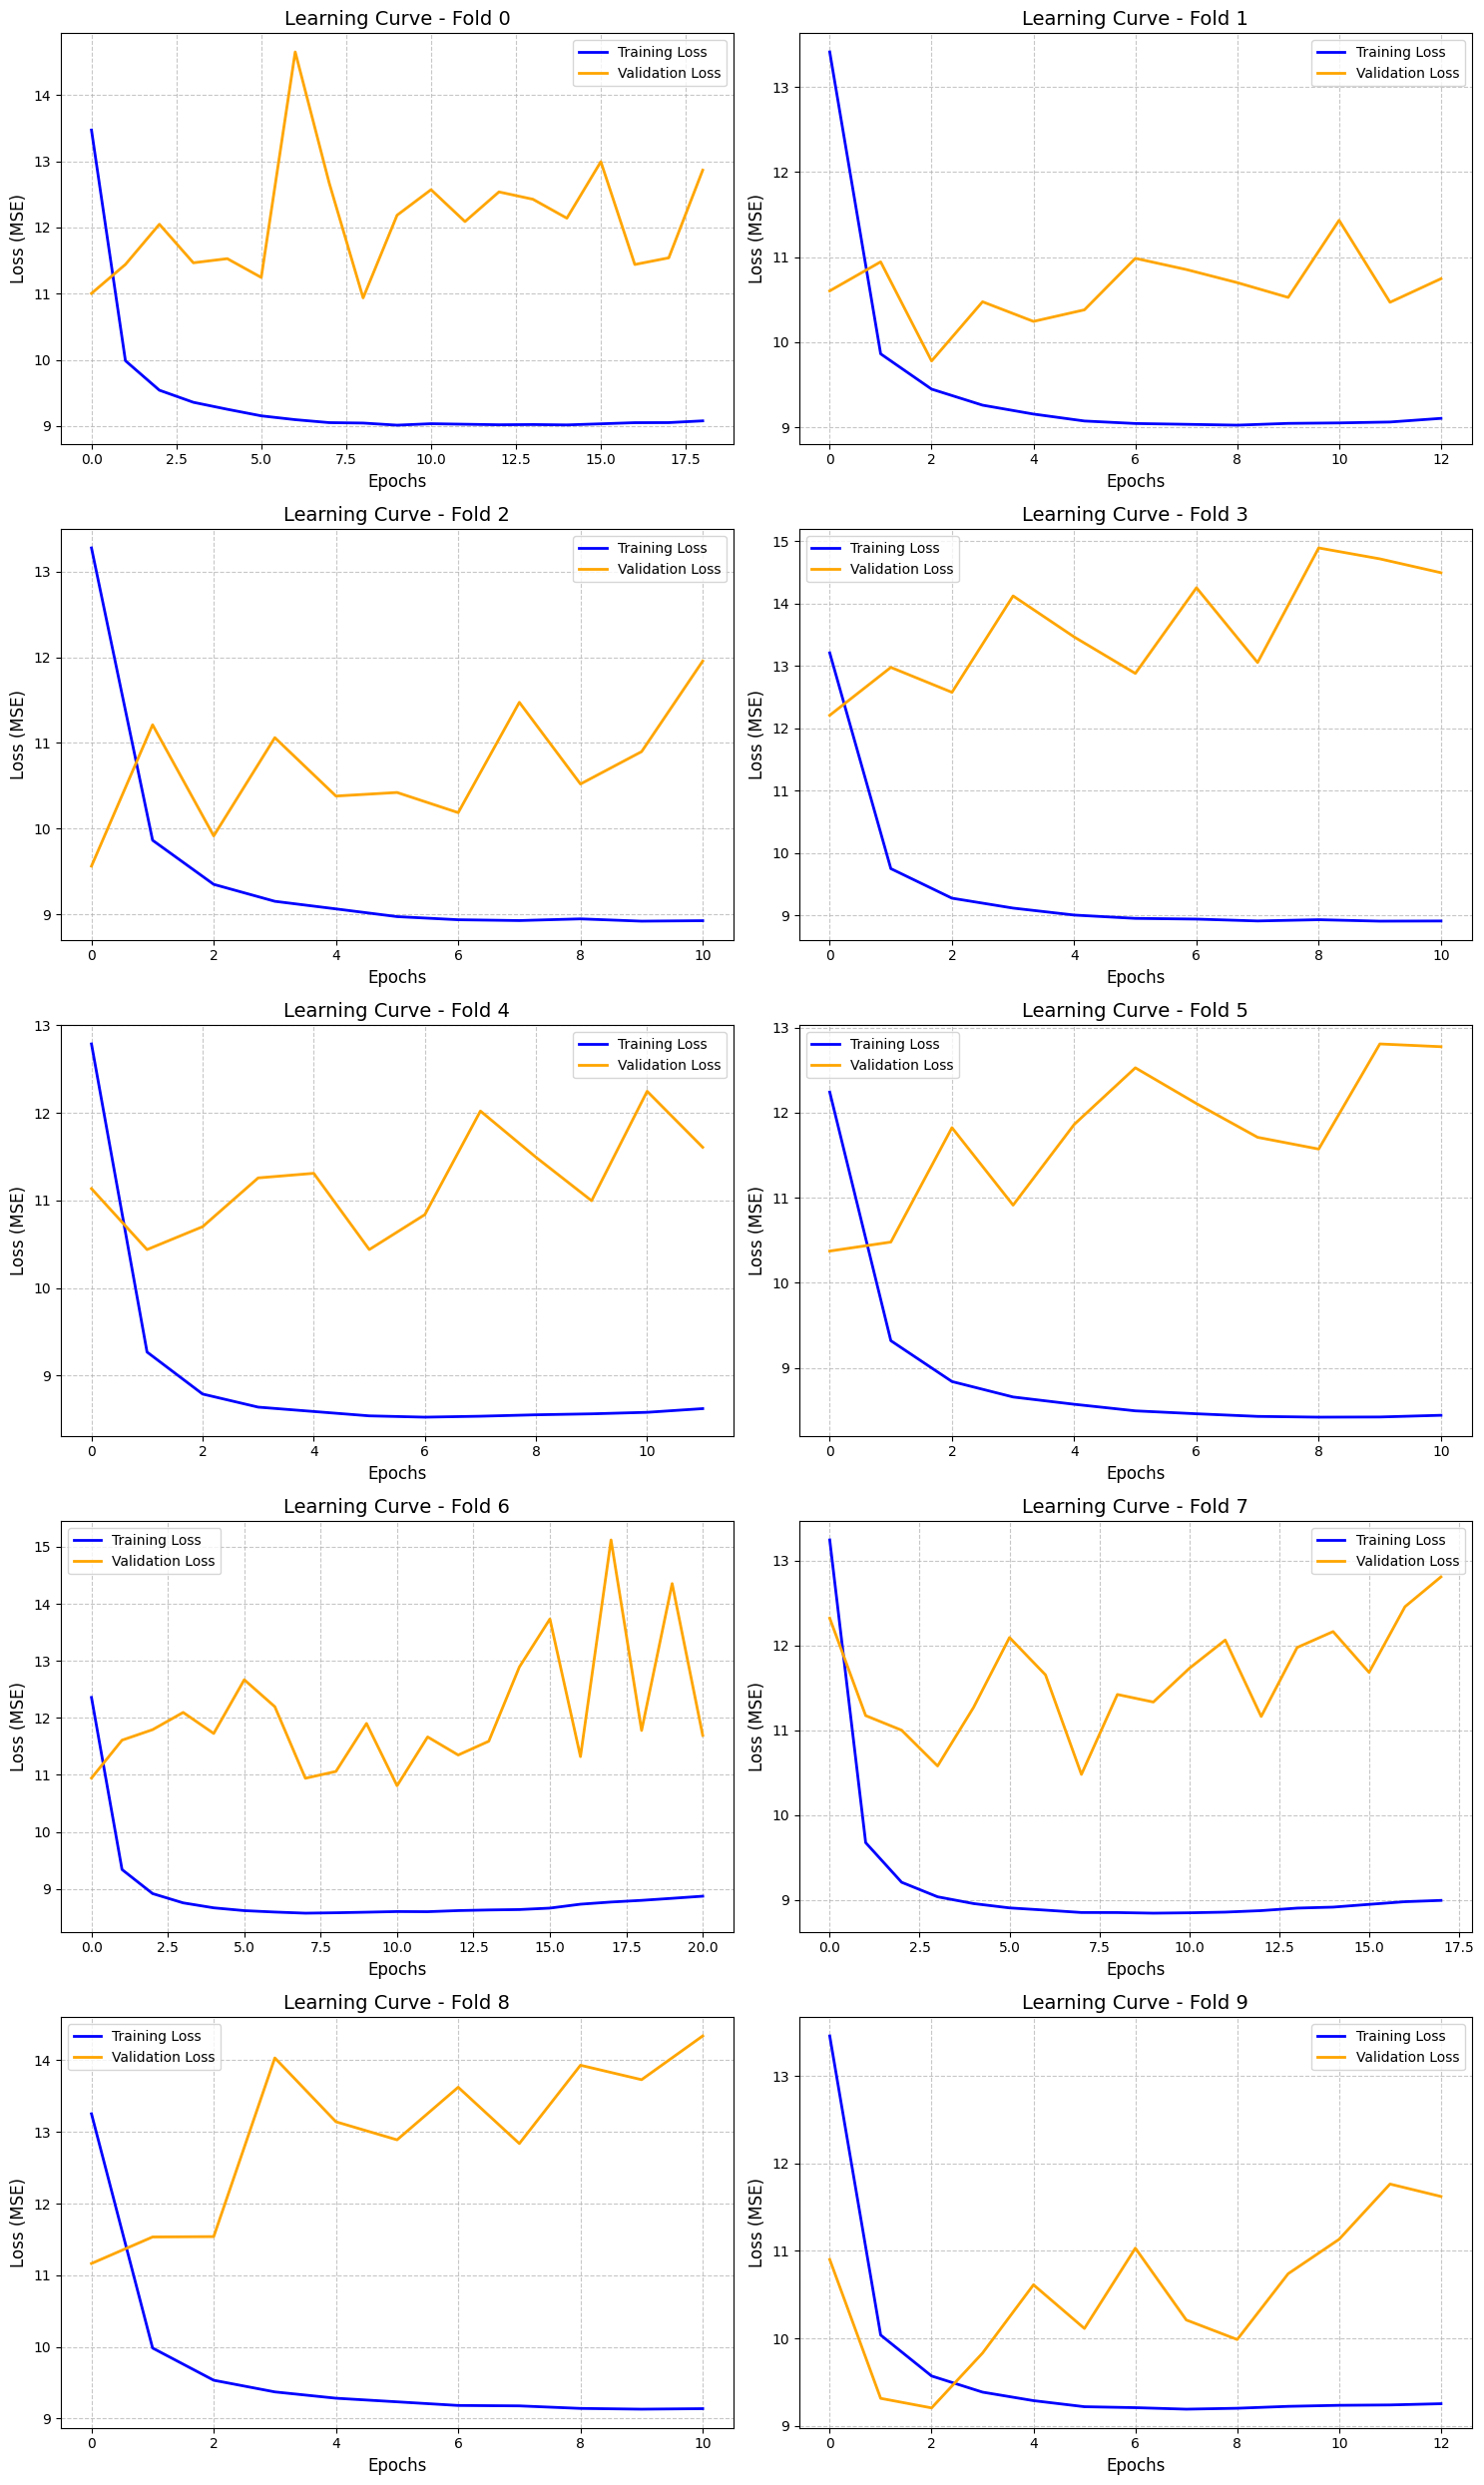

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/Lab_XAI_pytorch/experiments/exp_1_20260725_113507


In [5]:
k_fold_dict_1, save_dir_1 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_1")

### Experiment 2: batch_size = 256

=== Starting Experiment Pipeline: exp_2 ===
Created isolated environment at: experiments/exp_2_20260725_155710

--- Starting FOLD 0 ---


Early stopping at epoch 20
Train MSE: 7.470, Test MSE: 10.274, Train MAE: 2.071, Test MAE: 2.374

--- Starting FOLD 1 ---


Early stopping at epoch 14
Train MSE: 7.714, Test MSE: 10.007, Train MAE: 2.146, Test MAE: 2.491

--- Starting FOLD 2 ---


Early stopping at epoch 16
Train MSE: 7.264, Test MSE: 10.080, Train MAE: 2.056, Test MAE: 2.509

--- Starting FOLD 3 ---


Early stopping at epoch 19
Train MSE: 7.808, Test MSE: 13.746, Train MAE: 2.187, Test MAE: 2.876

--- Starting FOLD 4 ---


...

Early stopping at epoch 16
Train MSE: 7.447, Test MSE: 45.319, Train MAE: 2.122, Test MAE: 5.161

--- Starting FOLD 6 ---


Early stopping at epoch 13
Train MSE: 8.069, Test MSE: 38.438, Train MAE: 2.203, Test MAE: 4.662

--- Starting FOLD 7 ---


Early stopping at epoch 15
Train MSE: 7.531, Test MSE: 22.024, Train MAE: 2.109, Test MAE: 3.456

--- Starting FOLD 8 ---


Early stopping at epoch 18
Train MSE: 7.296, Test MSE: 12.245, Train MAE: 2.035, Test MAE: 2.871

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.971, Test MSE: 10.760, Train MAE: 2.141, Test MAE: 2.396

Execution 'exp_2' successfully completed in 2944.08s!
Generating Learning Curves...


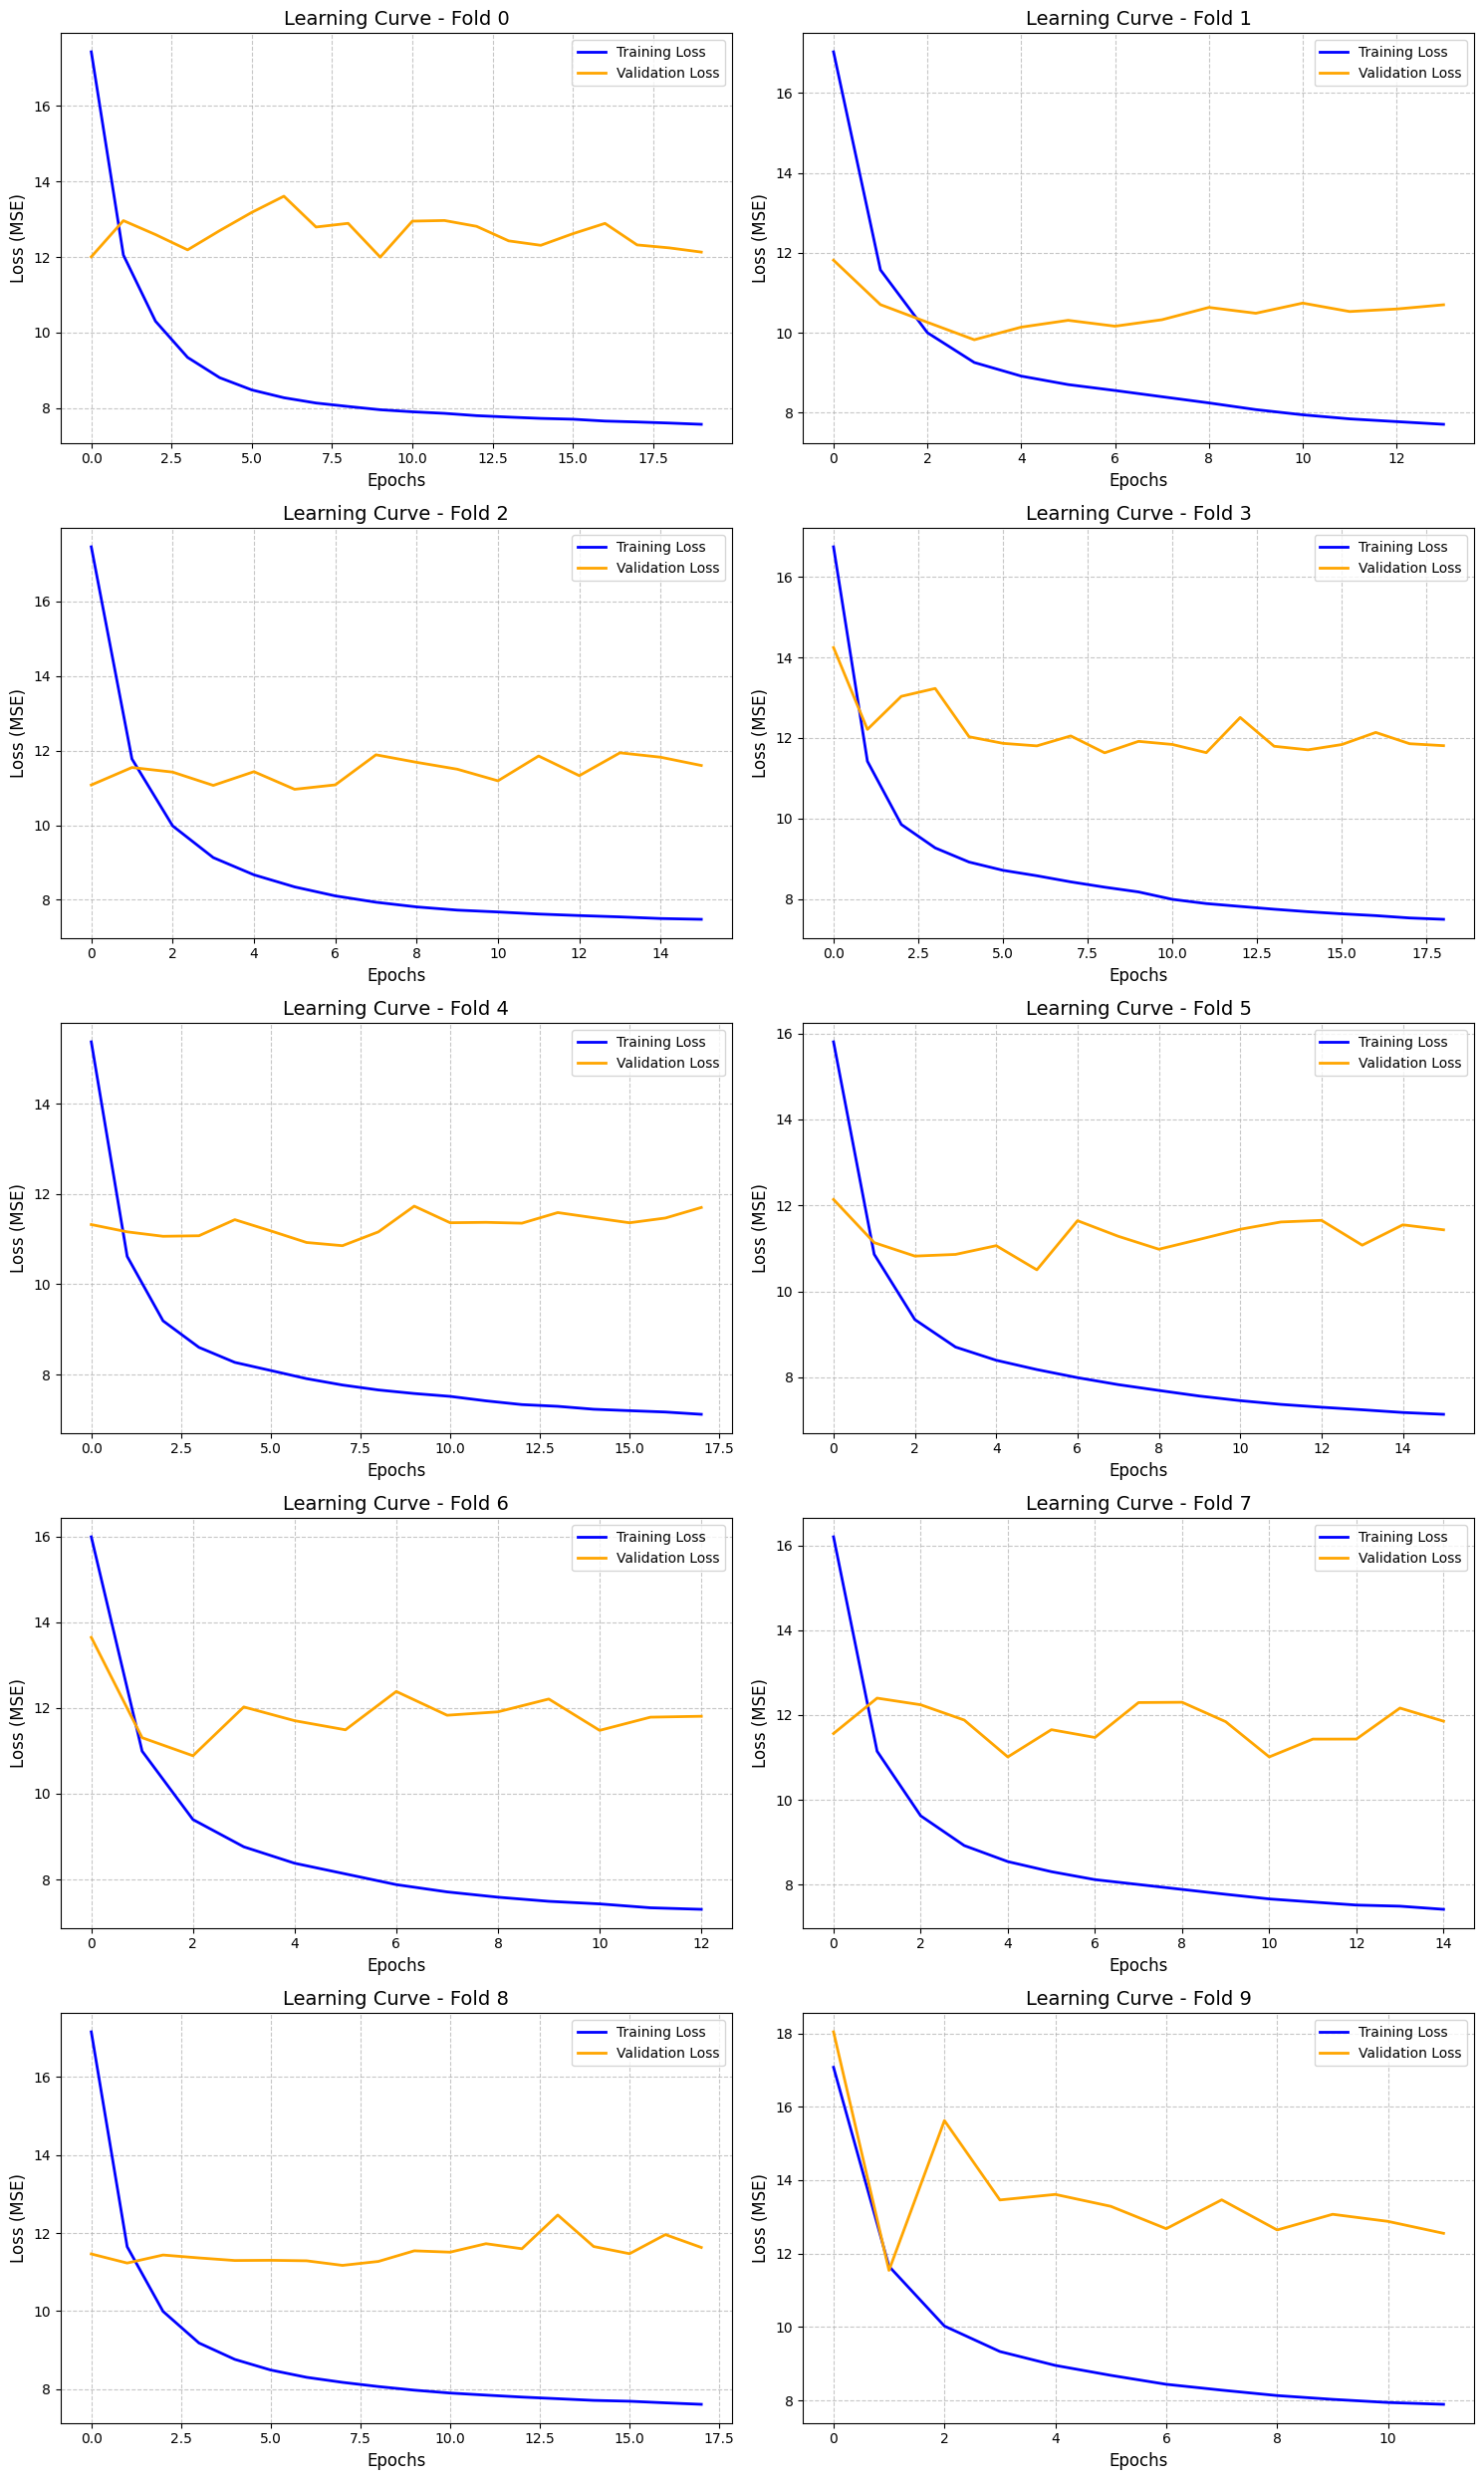

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/Lab_XAI_pytorch/experiments/exp_2_20260725_155710


In [6]:
k_fold_dict_2, save_dir_2 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_2")

In [7]:
print(k_fold_dict_2)

{'MAE': 3.283374703947548, 'MAPE': 0.2520742931446415, 'MSE': 20.046253991923, 'predictions': array([11.87760544, 11.87760544, 11.87760544, ..., 13.2814436 ,
       13.28100395, 13.2805624 ], shape=(1905841,)), 'execution_time': 2944.079303741455, 'histories': [{'train_loss': [np.float64(17.43148210838924), np.float64(12.051383518496667), np.float64(10.29952202070967), np.float64(9.341043359228003), np.float64(8.804058928767201), np.float64(8.480084639128474), np.float64(8.273352661173925), np.float64(8.13319520811164), np.float64(8.041692796225494), np.float64(7.955134724408433), np.float64(7.900977023144777), np.float64(7.859720442785669), np.float64(7.798882440713443), np.float64(7.760712662100535), np.float64(7.726236723288041), np.float64(7.704610718322461), np.float64(7.655371875712338), np.float64(7.631372125957997), np.float64(7.602892337717478), np.float64(7.56959932262754)], 'val_loss': [12.00428581237793, 12.962651252746582, 12.593527793884277, 12.188158988952637, 12.6976194

### Experiment 3: batch_size = 32 no flux

In [8]:
X_3, y_3, feature_names_3 = load_and_preprocess_data(dataset_path="../Data/MARSIS_historical_dataset.csv", orbit_path="../Data/orbit_to_remove", keep_flux=False)

In [ ]:
k_fold_dict_3, save_dir_3 = pipeline(X_3, y_3, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_3")

=== Starting Experiment Pipeline: exp_3 ===
Created isolated environment at: experiments/exp_3_20260725_215045

--- Starting FOLD 0 ---


Early stopping at epoch 17
Train MSE: 7.483, Test MSE: 12.427, Train MAE: 2.047, Test MAE: 2.393

--- Starting FOLD 1 ---


Early stopping at epoch 19
Train MSE: 7.341, Test MSE: 9.712, Train MAE: 2.029, Test MAE: 2.404

--- Starting FOLD 2 ---


Early stopping at epoch 17
Train MSE: 7.454, Test MSE: 10.761, Train MAE: 2.038, Test MAE: 2.608

--- Starting FOLD 3 ---


Early stopping at epoch 13
Train MSE: 8.026, Test MSE: 15.351, Train MAE: 2.167, Test MAE: 2.926

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.502, Test MSE: 47.099, Train MAE: 2.089, Test MAE: 5.006

--- Starting FOLD 6 ---


Early stopping at epoch 20
Train MSE: 7.417, Test MSE: 40.368, Train MAE: 2.061, Test MAE: 4.675

--- Starting FOLD 7 ---


Early stopping at epoch 16
Train MSE: 7.660, Test MSE: 19.562, Train MAE: 2.099, Test MAE: 3.140

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 8.867, Test MSE: 16.379, Train MAE: 2.313, Test MAE: 3.190

--- Starting FOLD 9 ---


Training:   0%|▌                                                                                                                                                                               | 3/1000 [04:45<26:22:45, 95.25s/it, Train MSE=9.5377, Val MSE=21.5386]

### Comparison between corresponding tensorflow and pytorch outputs

=== Starting Experiment Comparison Analysis ===
Analysis of exp tensorflow...
-> TensorFlow format detected. 10 MAE values extracted.
Analysis of exp pytorch...
-> PyTorch format detected. 10 MAE values extracted.


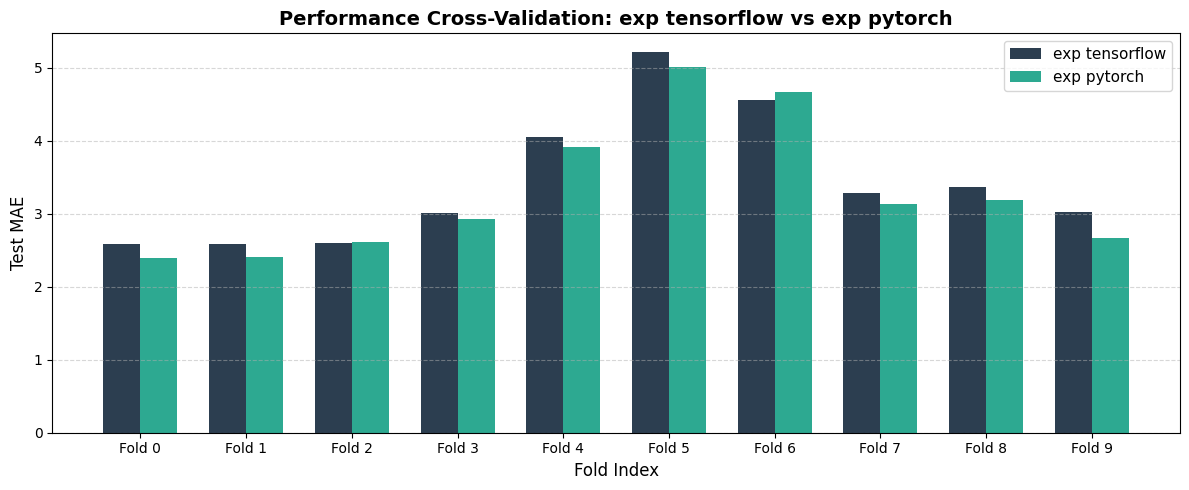

Plots saved in:
   - plots/comparison_20260726_104748_exp_tensorflow_vs_exp_pytorch.png
   - plots/comparison_20260726_104748_exp_tensorflow_vs_exp_pytorch.pdf
=== Comparison Process Completed ===


In [ ]:
compare_experiments_pipeline(
    "../2026_07_24_08_37_OUTPUTS_ORIGINAL_KERAS_ALL.txt", 
    "experiments/exp_3_20260725_215045/MAE_exp_3.txt", 
    exp1_label="exp tensorflow",
    exp2_label="exp pytorch",
    output_dir="plots", 
    show_plots=True
)

### Comparison between Exp 1 (with flux) and Exp 3 (no flux)

=== Starting Experiment Comparison Analysis ===
Analysis of exp 1 (flux)...
-> PyTorch format detected. 10 MAE values extracted.
Analysis of exp 2 (no flux)...
-> PyTorch format detected. 10 MAE values extracted.


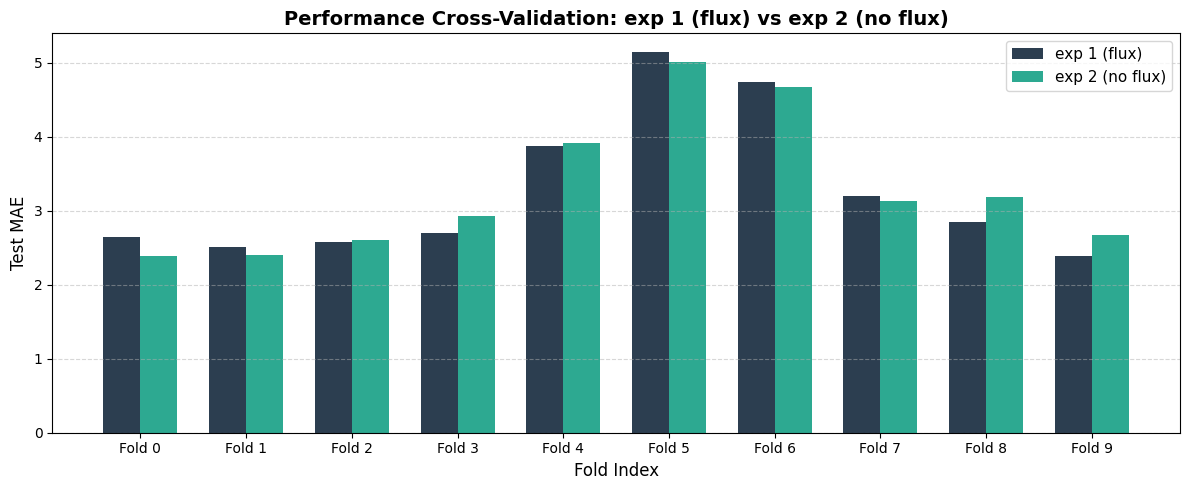

Plots saved in:
   - plots/comparison_20260726_105253_exp_1_(flux)_vs_exp_2_(no_flux).png
   - plots/comparison_20260726_105253_exp_1_(flux)_vs_exp_2_(no_flux).pdf
=== Comparison Process Completed ===


In [ ]:
compare_experiments_pipeline(
    "experiments/exp_1_20260725_113507/MAE_exp_1.txt", 
    "experiments/exp_3_20260725_215045/MAE_exp_3.txt", 
    exp1_label="exp 1 (flux)",
    exp2_label="exp 2 (no flux)",
    output_dir="plots", 
    show_plots=True
)

Loading result dictionaries...
 Plot 1 saved: comparison_plots/bar_chart_mse_20260726_105721 (.png and .pdf)


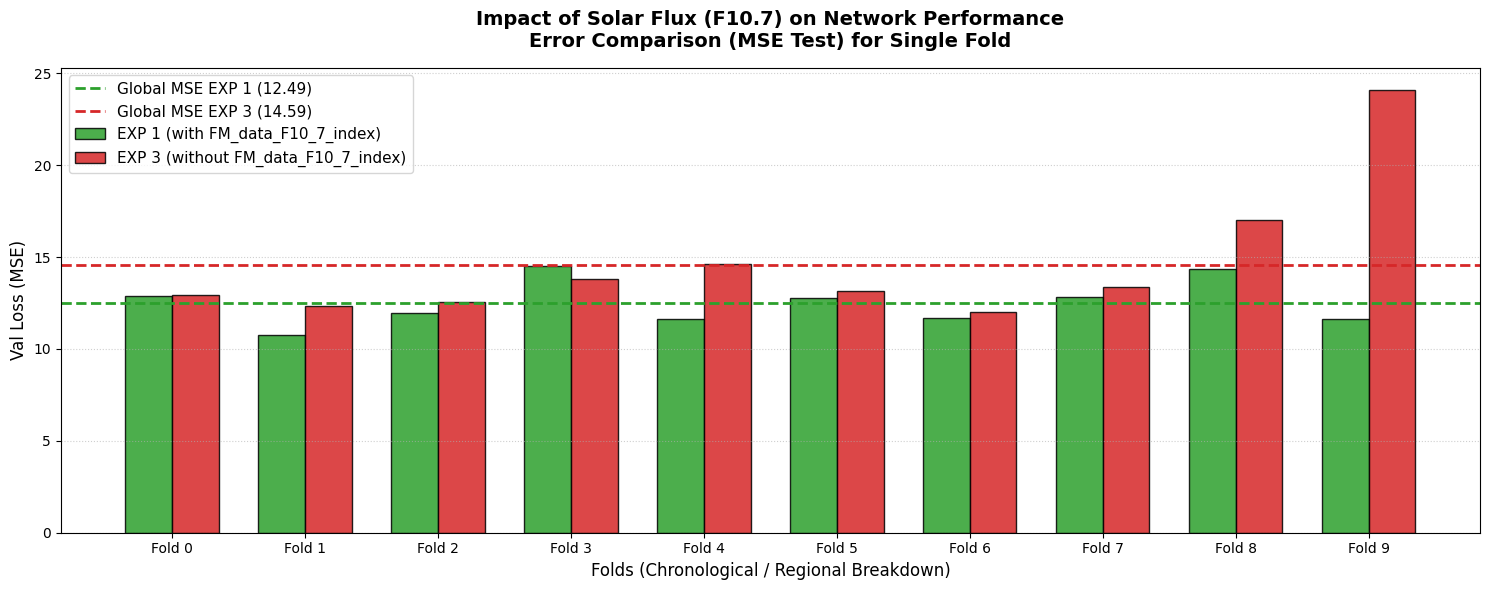

 Plot 2 saved in: comparison_plots/learning_curve_fold_9_20260726_105721 (.png and .pdf)


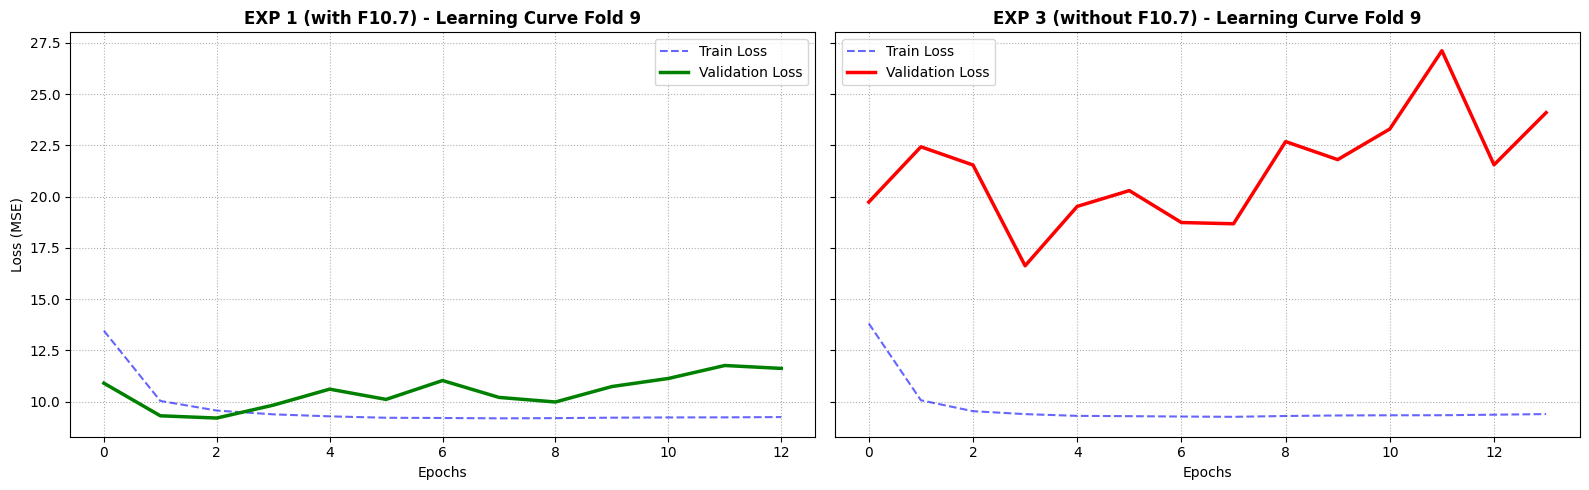

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

os.makedirs("comparison_plots", exist_ok=True)
timestamp_plots = datetime.now().strftime("%Y%m%d_%H%M%S")

# =====================================================================
# defining paths 
# =====================================================================
path_exp1 = "experiments/exp_1_20260725_113507/results_dict.pkl" # with solar flux
path_exp3 = "experiments/exp_3_20260725_215045/results_dict.pkl" # without solar flux

# loading results
print("Loading result dictionaries...")
with open(path_exp1, "rb") as f:
    dict_exp1 = pickle.load(f)

with open(path_exp3, "rb") as f:
    dict_exp3 = pickle.load(f)

# Automatic extraction of MSE values ​​from 'histories'
# Since the final `val_loss` value corresponds to the early stopping point (the fold's Test MSE)
mse_fold_exp1 = [h['val_loss'][-1] for h in dict_exp1['histories']]
mse_fold_exp3 = [h['val_loss'][-1] for h in dict_exp3['histories']]

# defining parameters for bar plot
num_folds = len(mse_fold_exp1)
folds = np.arange(num_folds)
width = 0.35  

# =====================================================================
# PLOT 1: COMPARATIVE BAR CHART - MSE TEST FOR FOLD
# =====================================================================
plt.figure(figsize=(15, 6))

# EXP 1 Bars (With Solar Flux)
plt.bar(folds - width/2, mse_fold_exp1, width, label='EXP 1 (with FM_data_F10_7_index)', 
        color='#2ca02c', alpha=0.85, edgecolor='black')

# EXP 3 Bars (Without Solar Flux)
plt.bar(folds + width/2, mse_fold_exp3, width, label='EXP 3 (without FM_data_F10_7_index)', 
        color='#d62728', alpha=0.85, edgecolor='black')

# Horizontal reference lines for the global mean error
global_mse_exp1 = np.mean(mse_fold_exp1)
global_mse_exp3 = np.mean(mse_fold_exp3)
plt.axhline(y=global_mse_exp1, color='#2ca02c', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 1 ({global_mse_exp1:.2f})')
plt.axhline(y=global_mse_exp3, color='#d62728', linestyle='--', linewidth=2, 
            label=f'Global MSE EXP 3 ({global_mse_exp3:.2f})')

plt.title("Impact of Solar Flux (F10.7) on Network Performance\nError Comparison (MSE Test) for Single Fold", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Folds (Chronological / Regional Breakdown)', fontsize=12)
plt.ylabel('Val Loss (MSE)', fontsize=12)
plt.xticks(folds, [f"Fold {i}" for i in folds], fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()

# --- saving PLOT 1 ---
base_name_plot1 = f"comparison_plots/bar_chart_mse_{timestamp_plots}"
plt.savefig(f"{base_name_plot1}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot1}.pdf", format='pdf', bbox_inches='tight')
print(f" Plot 1 saved: {base_name_plot1} (.png and .pdf)")

plt.show()

# =====================================================================
# PLOT 2: FOCUS ON THE CRITICAL FOLD (FOLD 9) - LEARNING CURVES
# =====================================================================
# Fold 9 shows the most significant impact in logs. Checking training.
critical_fold = 9

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# EXP 1 Curves (With Solar Flux)
h1 = dict_exp1['histories'][critical_fold]
axes[0].plot(h1['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[0].plot(h1['val_loss'], label='Validation Loss', color='green', linewidth=2.5)
axes[0].set_title(f"EXP 1 (with F10.7) - Learning Curve Fold {critical_fold}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss (MSE)")
axes[0].grid(True, linestyle=':')
axes[0].legend()

# EXP 3 Curves (Without Solar Flux)
h3 = dict_exp3['histories'][critical_fold]
axes[1].plot(h3['train_loss'], label='Train Loss', color='blue', alpha=0.6, linestyle='--')
axes[1].plot(h3['val_loss'], label='Validation Loss', color='red', linewidth=2.5)
axes[1].set_title(f"EXP 3 (without F10.7) - Learning Curve Fold {critical_fold}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].grid(True, linestyle=':')
axes[1].legend()

plt.tight_layout()

# --- saving PLOT 2 ---
base_name_plot2 = f"comparison_plots/learning_curve_fold_{critical_fold}_{timestamp_plots}"
plt.savefig(f"{base_name_plot2}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_plot2}.pdf", format='pdf', bbox_inches='tight')
print(f" Plot 2 saved in: {base_name_plot2} (.png and .pdf)")

plt.show()


### Comparison between Exp 1 (batch_size = 32) and Exp 2 (batch_size = 256)

=== Starting Experiment Comparison Analysis ===
Analysis of exp 1 (batch_size=32)...
-> PyTorch format detected. 10 MAE values extracted.
Analysis of exp 2 (batch_size=256)...
-> PyTorch format detected. 10 MAE values extracted.


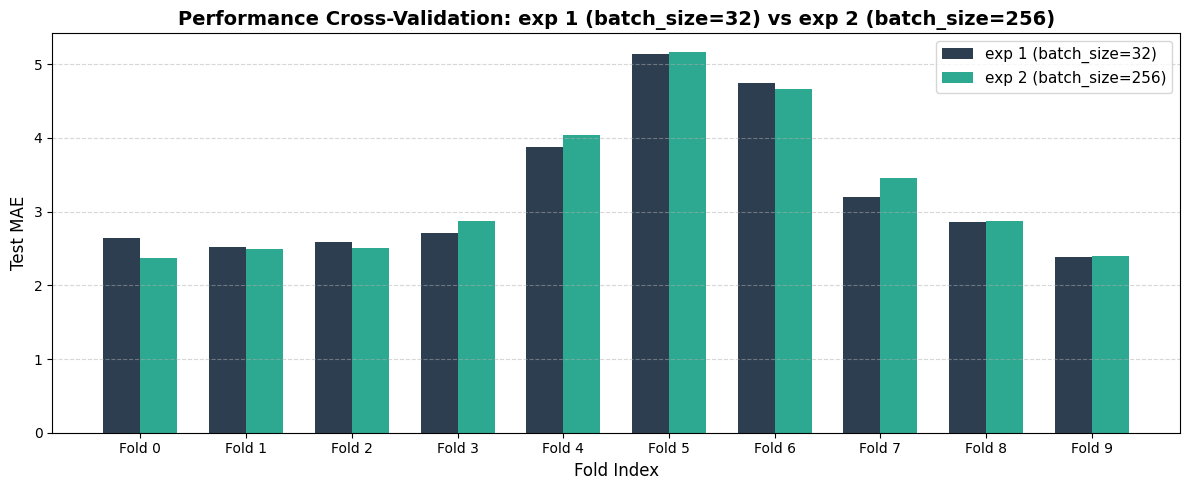

Plots saved in:
   - plots/comparison_20260726_110030_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).png
   - plots/comparison_20260726_110030_exp_1_(batch_size=32)_vs_exp_2_(batch_size=256).pdf
=== Comparison Process Completed ===


In [ ]:
compare_experiments_pipeline(
    "experiments/exp_1_20260725_113507/MAE_exp_1.txt", 
    "experiments/exp_2_20260725_155710/MAE_exp_2.txt", 
    exp1_label="exp 1 (batch_size=32)",
    exp2_label="exp 2 (batch_size=256)",
    output_dir="plots", 
    show_plots=True
)

## SHAP on Neural Network

### SHAP on experiment 2: Macro vs Micro Error Analysis

#### Data extraction using indices from previous pipeline k fold cross validation

In [ ]:
import re
import numpy as np
import os
from shap_utils.explain_with_shap import *

log_file_path = "experiments/exp_2_20260725_155710/MAE_exp_2.txt" 

# Dictionary for storing the reconstructed indices
extracted_test_indices = {}
fold_counter = 1

print(" Log reading and index reconstruction in progress...")

# reading from txt file
if os.path.exists(log_file_path):
    with open(log_file_path, 'r') as file:
        for line in file:
            # isolating the rows corresponding to the test set.
            if line.startswith("TEST:"):
                # re.findall(r'\d+', line) extracts all groups of numbers, ignoring parentheses and dots
                numbers = [int(n) for n in re.findall(r'\d+', line)]
                
                if len(numbers) >= 2:
                    start_idx = numbers[0]   # E.g. Fold 1: 190585
                    end_idx = numbers[-1]    # E.g. Fold 1: 381168
                    
                    # Generates the contiguous array: [190585, 190586, ..., 381168]
                    extracted_test_indices[fold_counter] = np.arange(start_idx, end_idx + 1)
                
                fold_counter += 1
else:
    raise FileNotFoundError(f"File non trovato al percorso: {log_file_path}")

# Global index-based allocation
total_samples = len(X)
all_indices = np.arange(total_samples)

# ==========================================
# DATA EXTRACTION - FOLD 1
# ==========================================
# The test set is the newly reconstructed array.
test_idx_f1 = extracted_test_indices[1]
# The training set consists of everything else (Global indices – Test indices).
train_idx_f1 = np.setdiff1d(all_indices, test_idx_f1) 

X_train_fold1 = X[train_idx_f1]
X_test_fold1  = X[test_idx_f1]

# ==========================================
# DATA EXTRACTION - FOLD 5 
# ==========================================
test_idx_f5 = extracted_test_indices[5]
train_idx_f5 = np.setdiff1d(all_indices, test_idx_f5)

X_train_fold5 = X[train_idx_f5]
X_test_fold5  = X[test_idx_f5]
# extracting also the actual targets to calculate the actual error on the waterfall charts.
y_test_fold5  = y[test_idx_f5]

print(" Operation completed successfully! The extracted data is:")
print(f"   - FOLD 1 -> Train: {X_train_fold1.shape}, Test: {X_test_fold1.shape}")
print(f"   - FOLD 5 -> Train: {X_train_fold5.shape}, Test: {X_test_fold5.shape}")


 Log reading and index reconstruction in progress...
 Operation completed successfully! The extracted data is:
   - FOLD 1 -> Train: (1715256, 19), Test: (190585, 19)
   - FOLD 5 -> Train: (1715257, 19), Test: (190584, 19)


In [17]:
# Preliminary extraction of feature names (including Solar Flux)
feature_names_2 = extract_feature_names(dataset_path="../Data/MARSIS_historical_dataset.csv", keep_flux=True)
input_dim_2 = len(feature_names_2)

#### Fold 1 and Fold 5


--- 1A. Running SHAP on FOLD 1 ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260725_155710/model_exp_2_1.pth | Scaler: experiments/exp_2_20260725_155710/scaler_chrono_exp_2_1.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
SHAP calculation completed.

--- 1B. Running SHAP on FOLD 5 ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260725_155710/model_exp_2_5.pth | Scaler: experiments/exp_2_20260725_155710/scaler_chrono_exp_2_5.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
SHAP calculation completed.



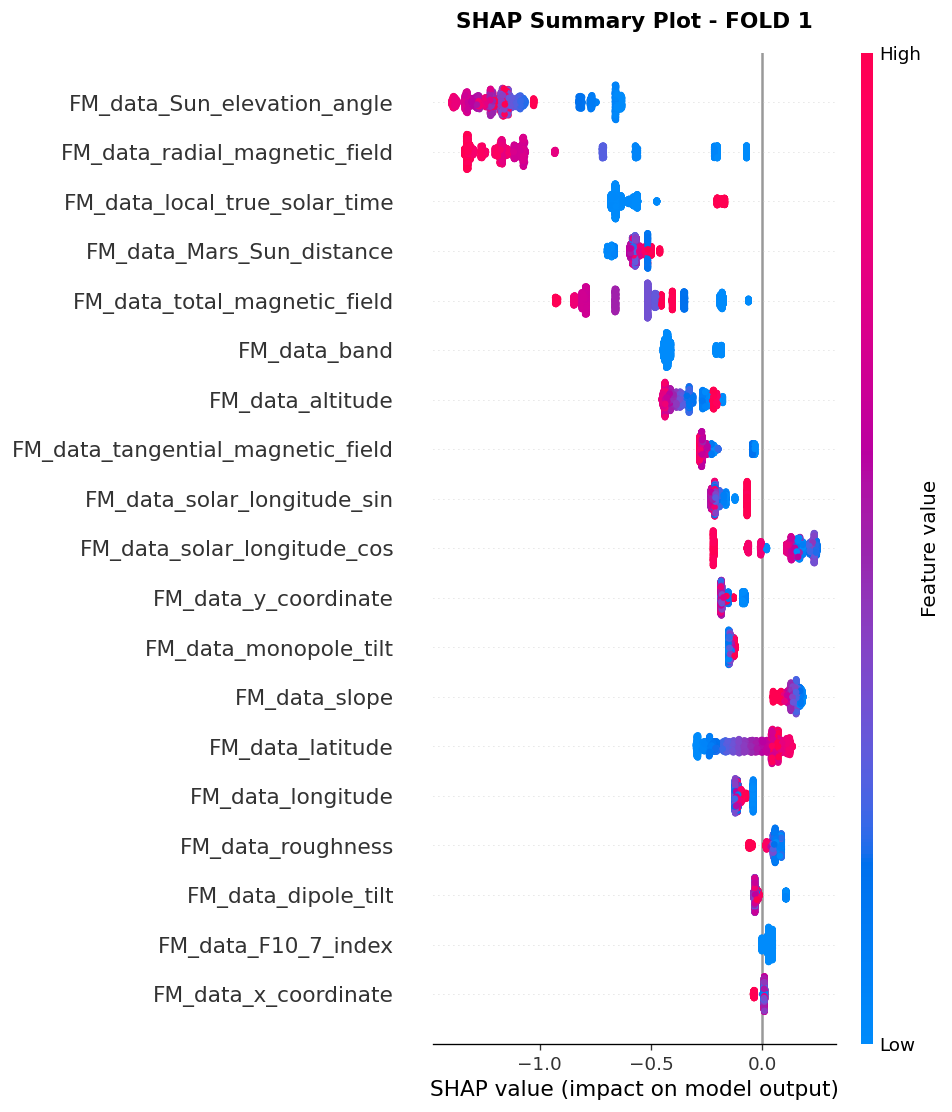
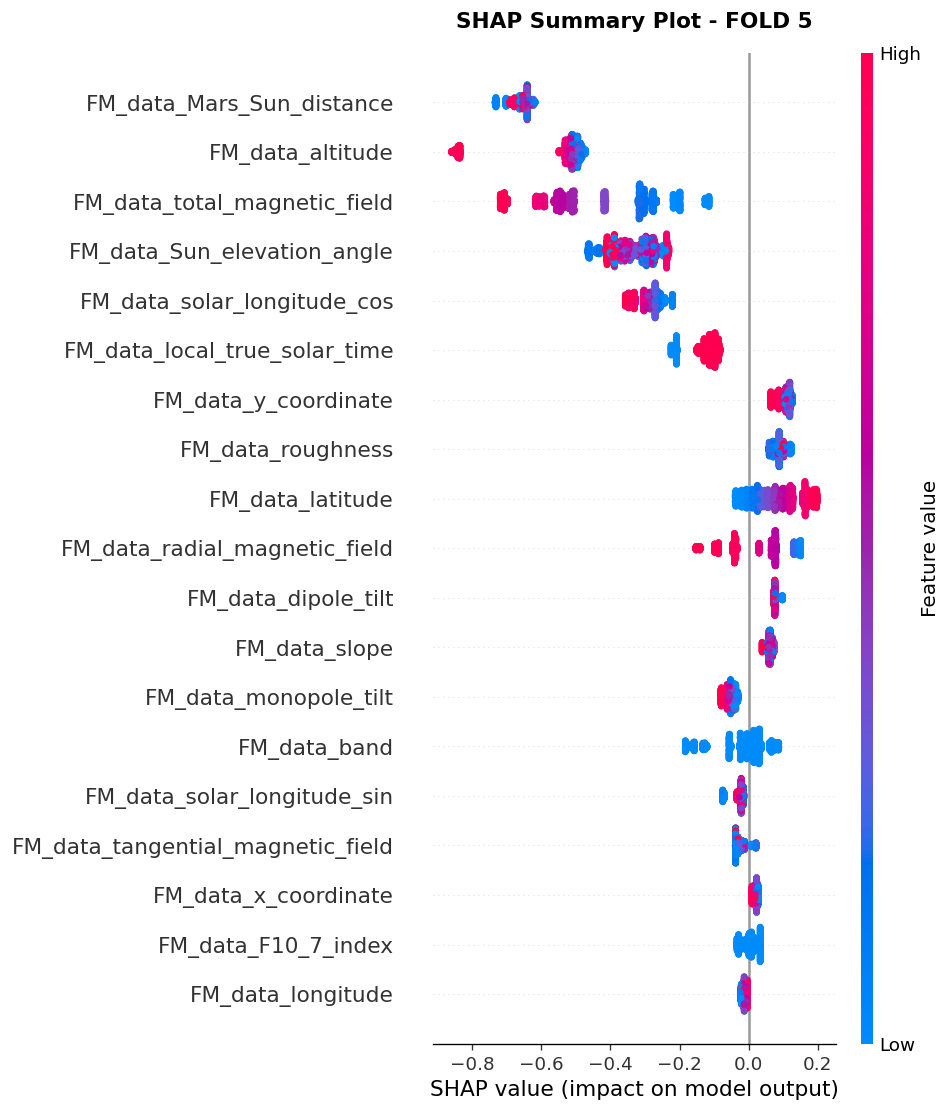

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
from IPython.display import display, HTML

from datetime import datetime

# generating the unique timestamp and creating the folder for the SHAP plots
timestamp_shap = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_plots", exist_ok=True)

# =====================================================================
# STEP 1: MACRO ANALYSIS - REGION COMPARISON (FOLD 1 vs FOLD 5)
# =====================================================================

print("\n--- 1A. Running SHAP on FOLD 1 ---")
model_fold1 = NeurNet(input_dim=input_dim_2)
weights_f1 = "experiments/exp_2_20260725_155710/model_exp_2_1.pth"
scaler_f1 = "experiments/exp_2_20260725_155710/scaler_chrono_exp_2_1.save"

shap_values_f1, X_test_scaled_f1, explainer_f1 = explain_with_shap(
    model=model_fold1,
    weights_path=weights_f1,
    scaler_path=scaler_f1,
    X_background_raw=X_train_fold1,  
    X_test_raw=X_test_fold1,          
    bg_limit=500,
    test_limit=2000
)

print("\n--- 1B. Running SHAP on FOLD 5 ---")
model_fold5 = NeurNet(input_dim=input_dim_2)
weights_f5 = "experiments/exp_2_20260725_155710/model_exp_2_5.pth" 
scaler_f5 = "experiments/exp_2_20260725_155710/scaler_chrono_exp_2_5.save"

shap_values_f5, X_test_scaled_f5, explainer_f5 = explain_with_shap(
    model=model_fold5,
    weights_path=weights_f5,
    scaler_path=scaler_f5,
    X_background_raw=X_train_fold5,  
    X_test_raw=X_test_fold5,          
    bg_limit=500,
    test_limit=2000
)

# Generating first image
fig1 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f1, X_test_scaled_f1, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 1", fontsize=13, fontweight='bold', pad=15)

base_f1 = f"shap_plots/shap_summary_fold1_{timestamp_shap}"
fig1.savefig(f"{base_f1}.png", dpi=600, bbox_inches='tight')
fig1.savefig(f"{base_f1}.pdf", format='pdf', bbox_inches='tight')

html_fold1 = fig_to_html_element(fig1)

# Generating second image
fig2 = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values_f5, X_test_scaled_f5, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 5", fontsize=13, fontweight='bold', pad=15)

base_f5 = f"shap_plots/shap_summary_fold5_{timestamp_shap}"
fig2.savefig(f"{base_f5}.png", dpi=600, bbox_inches='tight')
fig2.savefig(f"{base_f5}.pdf", format='pdf', bbox_inches='tight')

html_fold5 = fig_to_html_element(fig2)


# placing the two images side-by-side on the same line using a Flexbox container.
html_container = f"""
<div style="display: flex; justify-content: space-between; align-items: flex-start; width: 100%;">
    {html_fold1}
    {html_fold5}
</div>
"""

# final rendering in the notebook
display(HTML(html_container))

#### Micro analysis


--- 2. Extraction and analysis of the worst samples from Fold 5 ---
Indices of the most problematic samples in the Fold 5: [1547 1543 1139]
Corresponding absolute errors: [7.63201332 7.26409912 7.13290691]

Waterfall plot generation for the high-error sample (Index: 1547)...
   Plots saved in: shap_single_plots/waterfall_fold5_sample_1547_20260726_114744 (.png/.pdf)


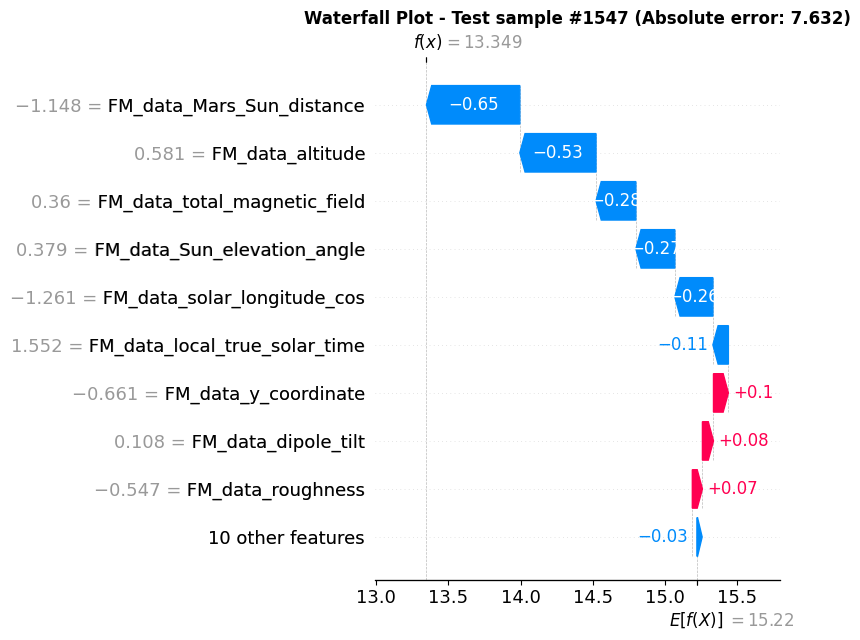


Waterfall plot generation for the high-error sample (Index: 1543)...
   Plots saved in: shap_single_plots/waterfall_fold5_sample_1543_20260726_114744 (.png/.pdf)


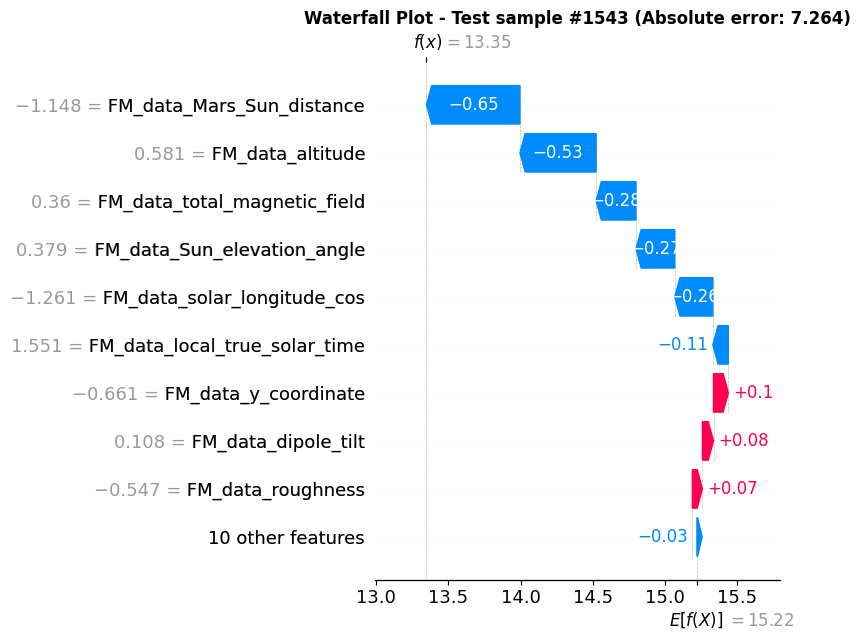


Waterfall plot generation for the high-error sample (Index: 1139)...
   Plots saved in: shap_single_plots/waterfall_fold5_sample_1139_20260726_114744 (.png/.pdf)


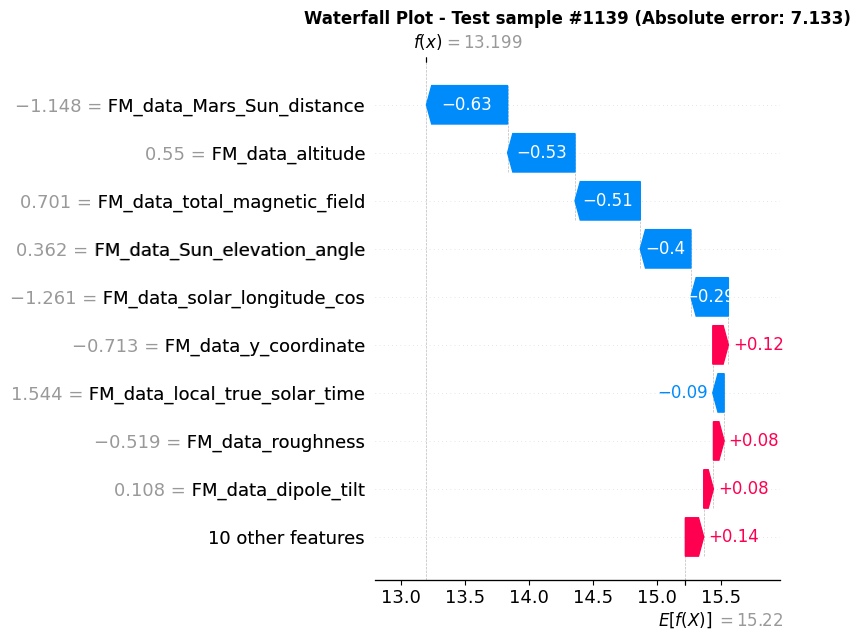

In [20]:
from datetime import datetime
import os

# generating the unique timestamp for this execution and creating the folder.
timestamp_single = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)

# =====================================================================
# STEP 2: micro analysis
# =====================================================================
print("\n--- 2. Extraction and analysis of the worst samples from Fold 5 ---")

# Generating model predictions to calculate the actual residual error.
model_fold5.to("cpu")
model_fold5.eval()
with torch.no_grad():
    # converting the already normalized test data into a PyTorch tensor.
    tensor_test_f5 = torch.tensor(X_test_scaled_f5, dtype=torch.float32)
    # Calculating network output and converting to a flat NumPy array.
    y_pred_f5 = model_fold5(tensor_test_f5).cpu().numpy().flatten()

limit = len(y_pred_f5)
absolute_errors = np.abs(y_pred_f5 - y_test_fold5[:limit].flatten())

# Extraction of the indices of the 3 samples with the highest error (ascending order, taking the last 3)
worst_samples_indices = np.argsort(absolute_errors)[-3:][::-1]

print(f"Indices of the most problematic samples in the Fold 5: {worst_samples_indices}")
print(f"Corresponding absolute errors: {absolute_errors[worst_samples_indices]}")

# Extraction of the baseline expected value from DeepExplainer
base_value = explainer_f5.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

# Generation of local waterfall plots for each isolated anomaly
for idx in worst_samples_indices:
    print(f"\nWaterfall plot generation for the high-error sample (Index: {idx})...")
    
    # packaging the vectors into a `shap.Explanation` container object.
    explanation_object = shap.Explanation(
        values=shap_values_f5[idx], 
        base_values=base_value, 
        data=X_test_scaled_f5[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object, show=False)
    plt.title(f"Waterfall Plot - Test sample #{idx} (Absolute error: {absolute_errors[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    base_name = f"shap_single_plots/waterfall_fold5_sample_{idx}_{timestamp_single}"
    plt.savefig(f"{base_name}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name}.pdf", format='pdf', bbox_inches='tight')
    print(f"   Plots saved in: {base_name} (.png/.pdf)")
    
    plt.show()

#### Investigating Fold 9


--- Data extraction for FOLD 9 ---
 - FOLD 9 -> Train: (1715257, 19), Test: (190584, 19)

--- Running SHAP on FOLD 9 ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260725_155710/model_exp_2_9.pth | Scaler: experiments/exp_2_20260725_155710/scaler_chrono_exp_2_9.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
SHAP calculation completed.
Variables shap_values_f9 and X_test_scaled_f9 successfully generated and ready for the Dependence Plot!

--- 2. SHAP analysis of the single feature (Solar Flux) on Fold 9 ---
Generating SHAP Dependence Plot for 'FM_data_F10_7_index'...
    Dependence Plot saved.


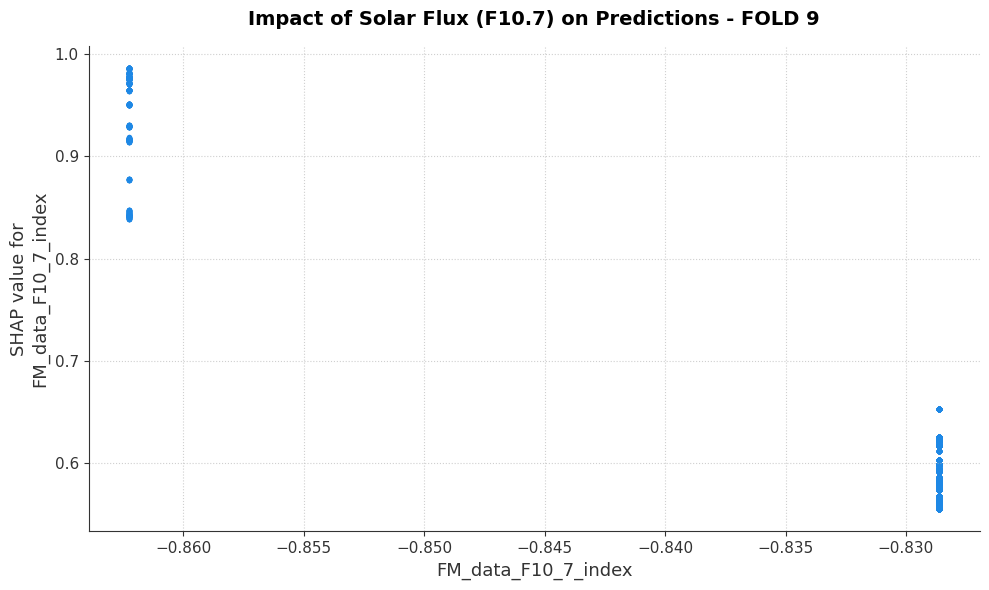


--- 2.5 Continuous Line Generation (Model Output vs. Solar Flux) ---
    Solid line plot successfully saved.


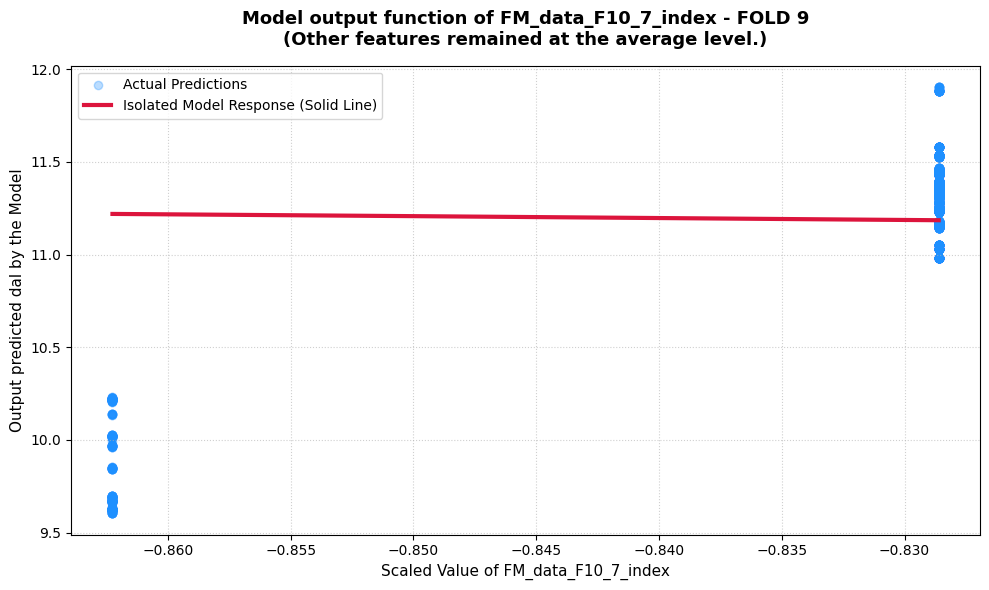


--- 3. Extraction and analysis of the worst samples from Fold 9 (Waterfall) ---
Indices of the most problematic samples in Fold 9: [1250 1215 1819]
Corresponding absolute errors: [4.95138168 4.78344345 4.76721478]
Waterfall plot generation for the high-error sample from Fold 9 (Index: 1250)...
    Waterfall plot saved in: shap_single_plots/waterfall_fold9_sample_1250_20260726_115258 (.png/.pdf)


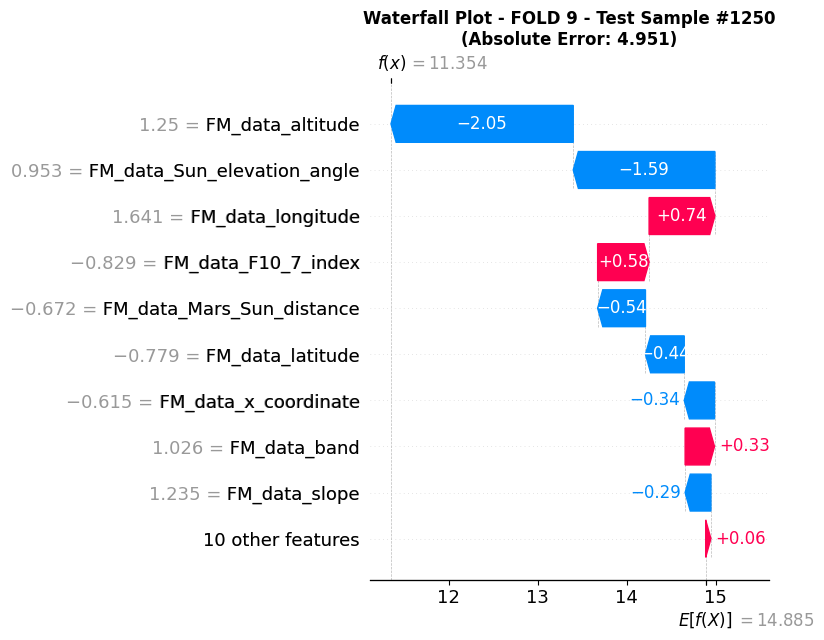

Waterfall plot generation for the high-error sample from Fold 9 (Index: 1215)...
    Waterfall plot saved in: shap_single_plots/waterfall_fold9_sample_1215_20260726_115258 (.png/.pdf)


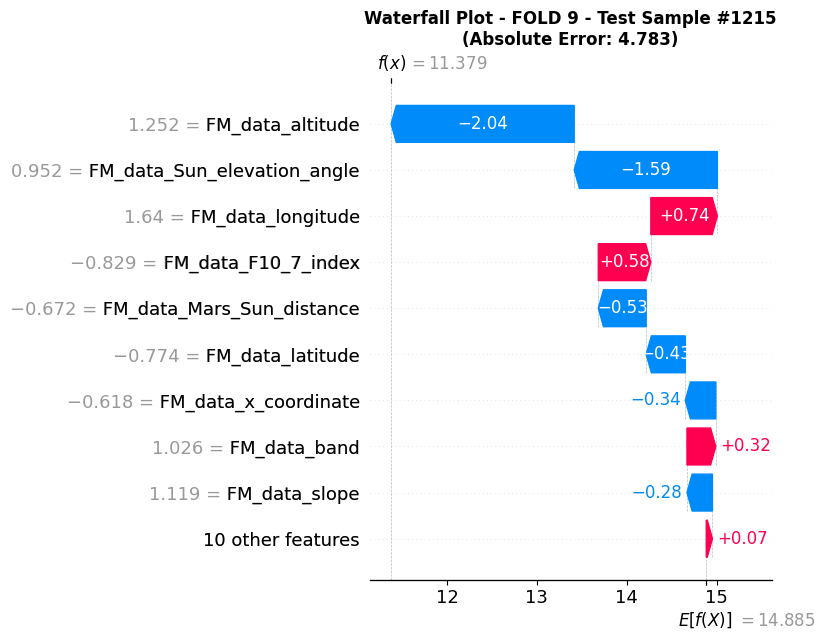

Waterfall plot generation for the high-error sample from Fold 9 (Index: 1819)...
    Waterfall plot saved in: shap_single_plots/waterfall_fold9_sample_1819_20260726_115258 (.png/.pdf)


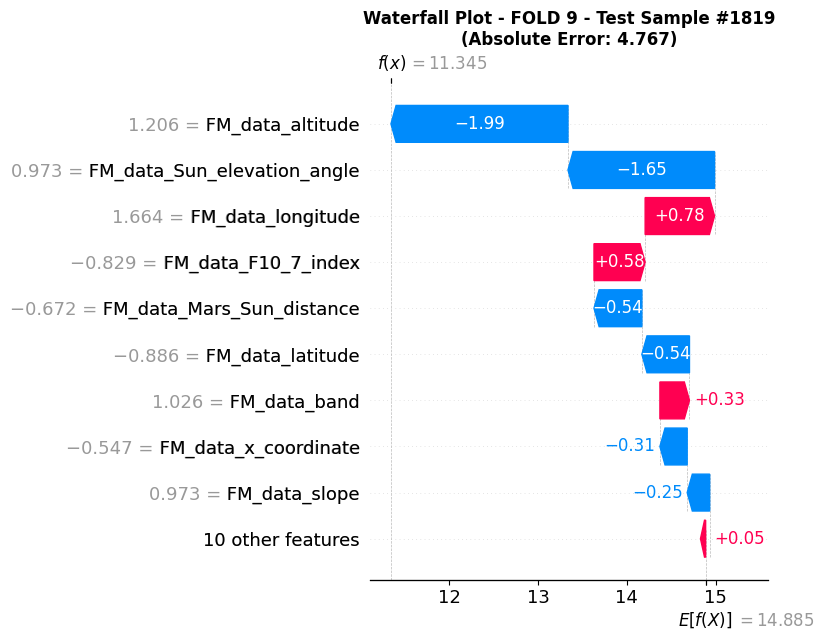

In [21]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
from datetime import datetime
from shap_utils.explain_with_shap import *

# =====================================================================
# STEP 1.5: Preparation of data extraction and SHAP for Fold 9
# =====================================================================
print("\n--- Data extraction for FOLD 9 ---")

# Reconstruction of the Train and Test matrices specific to Fold 9
test_idx_f9 = extracted_test_indices[9]
train_idx_f9 = np.setdiff1d(all_indices, test_idx_f9)

X_train_fold9 = X[train_idx_f9]
X_test_fold9  = X[test_idx_f9]
y_test_fold9 = y[test_idx_f9]

print(f" - FOLD 9 -> Train: {X_train_fold9.shape}, Test: {X_test_fold9.shape}")

print("\n--- Running SHAP on FOLD 9 ---")

model_fold9 = NeurNet(input_dim=input_dim_2)

weights_f9 = "experiments/exp_2_20260725_155710/model_exp_2_9.pth" 
scaler_f9  = "experiments/exp_2_20260725_155710/scaler_chrono_exp_2_9.save"

# Generating SHAP values
shap_values_f9, X_test_scaled_f9, explainer_f9 = explain_with_shap(
    model=model_fold9,
    weights_path=weights_f9,
    scaler_path=scaler_f9,
    X_background_raw=X_train_fold9,  
    X_test_raw=X_test_fold9,         
    bg_limit=500,                    
    test_limit=2000                  
)

print("Variables shap_values_f9 and X_test_scaled_f9 successfully generated and ready for the Dependence Plot!")

timestamp_single_9 = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("shap_single_plots", exist_ok=True)


# =====================================================================
# STEP 2: analyzing - FOLD 9 (Solar Flux)
# =====================================================================
print("\n--- 2. SHAP analysis of the single feature (Solar Flux) on Fold 9 ---")

target_feature_9 = 'FM_data_F10_7_index'

if target_feature_9 not in feature_names_2:
    print(f"Error: Feature '{target_feature_9}' is not in feature_names_2.")
else:
    print(f"Generating SHAP Dependence Plot for '{target_feature_9}'...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    shap.dependence_plot(
        target_feature_9,
        shap_values_f9,          
        X_test_scaled_f9,        
        feature_names=feature_names_2,
        ax=ax,
        show=False,
        interaction_index=None   
    )
    
    plt.title(f"Impact of Solar Flux (F10.7) on Predictions - FOLD 9", fontsize=14, fontweight='bold', pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    base_name_dep = f"shap_single_plots/dependence_fold9_solar_flux_{timestamp_single_9}"
    plt.savefig(f"{base_name_dep}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_dep}.pdf", format='pdf', bbox_inches='tight')
    print(f"    Dependence Plot saved.")
    plt.show()

# =====================================================================
# STEP 2.5: PARTIAL DEPENDENCE - FOLD 9
# =====================================================================
print("\n--- 2.5 Continuous Line Generation (Model Output vs. Solar Flux) ---")

# Finding the index of the Solar Flux column.
target_idx = feature_names_2.index(target_feature_9)

# Creating a "baseline sample" by fixing all other features at their mean values.
X_mean_background = np.mean(X_test_scaled_f9, axis=0, keepdims=True)

# Generating 100 perfectly continuous points from the minimum value to the maximum.
min_val = X_test_scaled_f9[:, target_idx].min()
max_val = X_test_scaled_f9[:, target_idx].max()
sweep_values = np.linspace(min_val, max_val, 100)

X_synthetic = np.repeat(X_mean_background, 100, axis=0)
X_synthetic[:, target_idx] = sweep_values

# making the neural network predict these 100 synthetic points.
model_fold9.to("cpu")
model_fold9.eval()
with torch.no_grad():
    tensor_synthetic = torch.tensor(X_synthetic, dtype=torch.float32)
    y_synthetic_pred = model_fold9(tensor_synthetic).cpu().numpy().flatten()
    
    # calculating also the actual predictions in order to plot them in the background.
    tensor_real = torch.tensor(X_test_scaled_f9, dtype=torch.float32)
    y_real_pred = model_fold9(tensor_real).cpu().numpy().flatten()

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test_scaled_f9[:, target_idx], y_real_pred, color='dodgerblue', alpha=0.3, label='Actual Predictions')

ax.plot(sweep_values, y_synthetic_pred, color='crimson', linewidth=3, label='Isolated Model Response (Solid Line)')

plt.title(f"Model output function of {target_feature_9} - FOLD 9\n(Other features remained at the average level.)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f"Scaled Value of {target_feature_9}", fontsize=11)
plt.ylabel("Output predicted dal by the Model", fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Saving
base_name_line = f"shap_single_plots/continuous_line_fold9_solar_flux_{timestamp_single_9}"
plt.savefig(f"{base_name_line}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{base_name_line}.pdf", format='pdf', bbox_inches='tight')
print(f"    Solid line plot successfully saved.")

plt.show()


# =====================================================================
# STEP 3: Waterfall plot for the worst samples (Fold 9)
# =====================================================================
print("\n--- 3. Extraction and analysis of the worst samples from Fold 9 (Waterfall) ---")

# Generating model predictions to calculate the residual on Fold 9
model_fold9.to("cpu")
model_fold9.eval()
with torch.no_grad():
    tensor_test_f9 = torch.tensor(X_test_scaled_f9, dtype=torch.float32)
    y_pred_f9 = model_fold9(tensor_test_f9).cpu().numpy().flatten()

limit_f9 = len(y_pred_f9)
absolute_errors_f9 = np.abs(y_pred_f9 - y_test_fold9[:limit_f9].flatten())

# Extraction of the indices of the 3 samples with the highest error in Fold 9
worst_samples_f9 = np.argsort(absolute_errors_f9)[-3:][::-1]

print(f"Indices of the most problematic samples in Fold 9: {worst_samples_f9}")
print(f"Corresponding absolute errors: {absolute_errors_f9[worst_samples_f9]}")

# Extraction of the baseline expected value from the Fold 9 DeepExplainer
base_value_f9 = explainer_f9.expected_value
if isinstance(base_value_f9, (list, np.ndarray)):
    base_value_f9 = base_value_f9[0]

# High-quality generation and saving cycle for every Fold 9 anomaly.
for idx in worst_samples_f9:
    print(f"Waterfall plot generation for the high-error sample from Fold 9 (Index: {idx})...")
    
    explanation_object_f9 = shap.Explanation(
        values=shap_values_f9[idx], 
        base_values=base_value_f9, 
        data=X_test_scaled_f9[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object_f9, show=False)
    plt.title(f"Waterfall Plot - FOLD 9 - Test Sample #{idx}\n(Absolute Error: {absolute_errors_f9[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    # Saving
    base_name_water = f"shap_single_plots/waterfall_fold9_sample_{idx}_{timestamp_single_9}"
    plt.savefig(f"{base_name_water}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{base_name_water}.pdf", format='pdf', bbox_inches='tight')
    print(f"    Waterfall plot saved in: {base_name_water} (.png/.pdf)")
    
    plt.show()

### Experiment 4: training neural network (batch size = 256) with lagged dataset

In [ ]:
from utils.generate_lagged_dataset import *
# SONO ARRIVATO QUI

In [12]:
import pandas as pd

# Carica un attimo il file solo per leggere le colonne
temp_df = pd.read_csv("Data/MARSIS_historical_dataset.csv", nrows=0)
print(temp_df.columns.tolist())

['FM_data_altitude;FM_data_band;FM_data_dipole_tilt;FM_data_ephemeris_time;FM_data_F10_7_index;FM_data_frequency;FM_data_latitude;FM_data_local_true_solar_time;FM_data_longitude;FM_data_Mars_Sun_distance;FM_data_median_corrected_echo_power;FM_data_monopole_tilt;FM_data_orbit_number;FM_data_peak_corrected_echo_power;FM_data_peak_distorted_echo_power;FM_data_peak_simulated_echo_power;FM_data_radial_magnetic_field;FM_data_roughness;FM_data_slope;FM_data_solar_longitude;FM_data_Sun_elevation_angle;FM_data_tangential_magnetic_field;FM_data_total_magnetic_field;FM_data_x_coordinate;FM_data_y_coordinate']


The code below moves the solar flux value back by one month.

In [13]:
df_1_month_lag = generate_lagged_dataset(
    input_csv_path="Data/MARSIS_historical_dataset.csv",
    output_csv_path="Data/MARSIS_historical_dataset_LAGGED_1M.csv",
    time_col="FM_data_ephemeris_time",
    feature_col="FM_data_F10_7_index",
    lag_months=1,
    drop_na=True
)

=== PREPARAZIONE DATASET CON LAG (FM_data_F10_7_index A -1 MESE/I) ===
⏱️ Rilevato tempo numerico (Ephemeris Time in secondi). Calcolo offset matematico...
Righe senza storico eliminate. Dimensione finale dataset: (4213548, 25)
✅ Nuovo dataset salvato con successo in: Data/MARSIS_historical_dataset_LAGGED_1M.csv



In [14]:
X_4, y_4, feature_names_4 = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset_LAGGED_1M.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

In [15]:
import pandas as pd

# 1. Controlliamo se X_4 e y_4 sono effettivamente vuoti
print(f"Dimensioni di X_4: {X_4.shape}")
print(f"Dimensioni di y_4: {y_4.shape}")

# 2. Controlliamo quante righe ha il CSV che stai leggendo
csv_path = "Data/MARSIS_historical_dataset_LAGGED_1M.csv" # Metti il path corretto se diverso
df_check = pd.read_csv(csv_path, sep=';')
print(f"\nRighe totali nel CSV: {len(df_check)}")

# 3. Controlliamo quante righe sopravvivono al filtro della frequenza
df_freq = df_check[df_check['FM_data_frequency'] == 4000000.0]
print(f"Righe dopo il filtro frequenza a 4MHz: {len(df_freq)}")

Dimensioni di X_4: (1896529, 19)
Dimensioni di y_4: (1896529,)

Righe totali nel CSV: 4213548
Righe dopo il filtro frequenza a 4MHz: 2074005


=== Starting Experiment Pipeline: exp_4 ===
Created isolated environment at: experiments/exp_4_20260524_160239

--- Starting FOLD 0 ---


Early stopping at epoch 31
Train MSE: 6.735, Test MSE: 12.416, Train MAE: 1.969, Test MAE: 2.627

--- Starting FOLD 1 ---


Early stopping at epoch 32
Train MSE: 6.484, Test MSE: 10.880, Train MAE: 1.905, Test MAE: 2.546

--- Starting FOLD 2 ---


Early stopping at epoch 16
Train MSE: 7.707, Test MSE: 9.913, Train MAE: 2.156, Test MAE: 2.485

--- Starting FOLD 3 ---


Early stopping at epoch 17
Train MSE: 7.328, Test MSE: 16.269, Train MAE: 2.078, Test MAE: 3.012

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.575, Test MSE: 51.073, Train MAE: 2.099, Test MAE: 5.391

--- Starting FOLD 6 ---


Early stopping at epoch 16
Train MSE: 7.212, Test MSE: 39.946, Train MAE: 2.053, Test MAE: 4.716

--- Starting FOLD 7 ---


Early stopping at epoch 21
Train MSE: 6.756, Test MSE: 26.966, Train MAE: 1.967, Test MAE: 3.653

--- Starting FOLD 8 ---


Early stopping at epoch 22
Train MSE: 7.273, Test MSE: 12.346, Train MAE: 2.074, Test MAE: 2.771

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.947, Test MSE: 11.341, Train MAE: 2.130, Test MAE: 2.621

Execution 'exp_4' successfully completed in 3277.20s!
Generating Learning Curves...


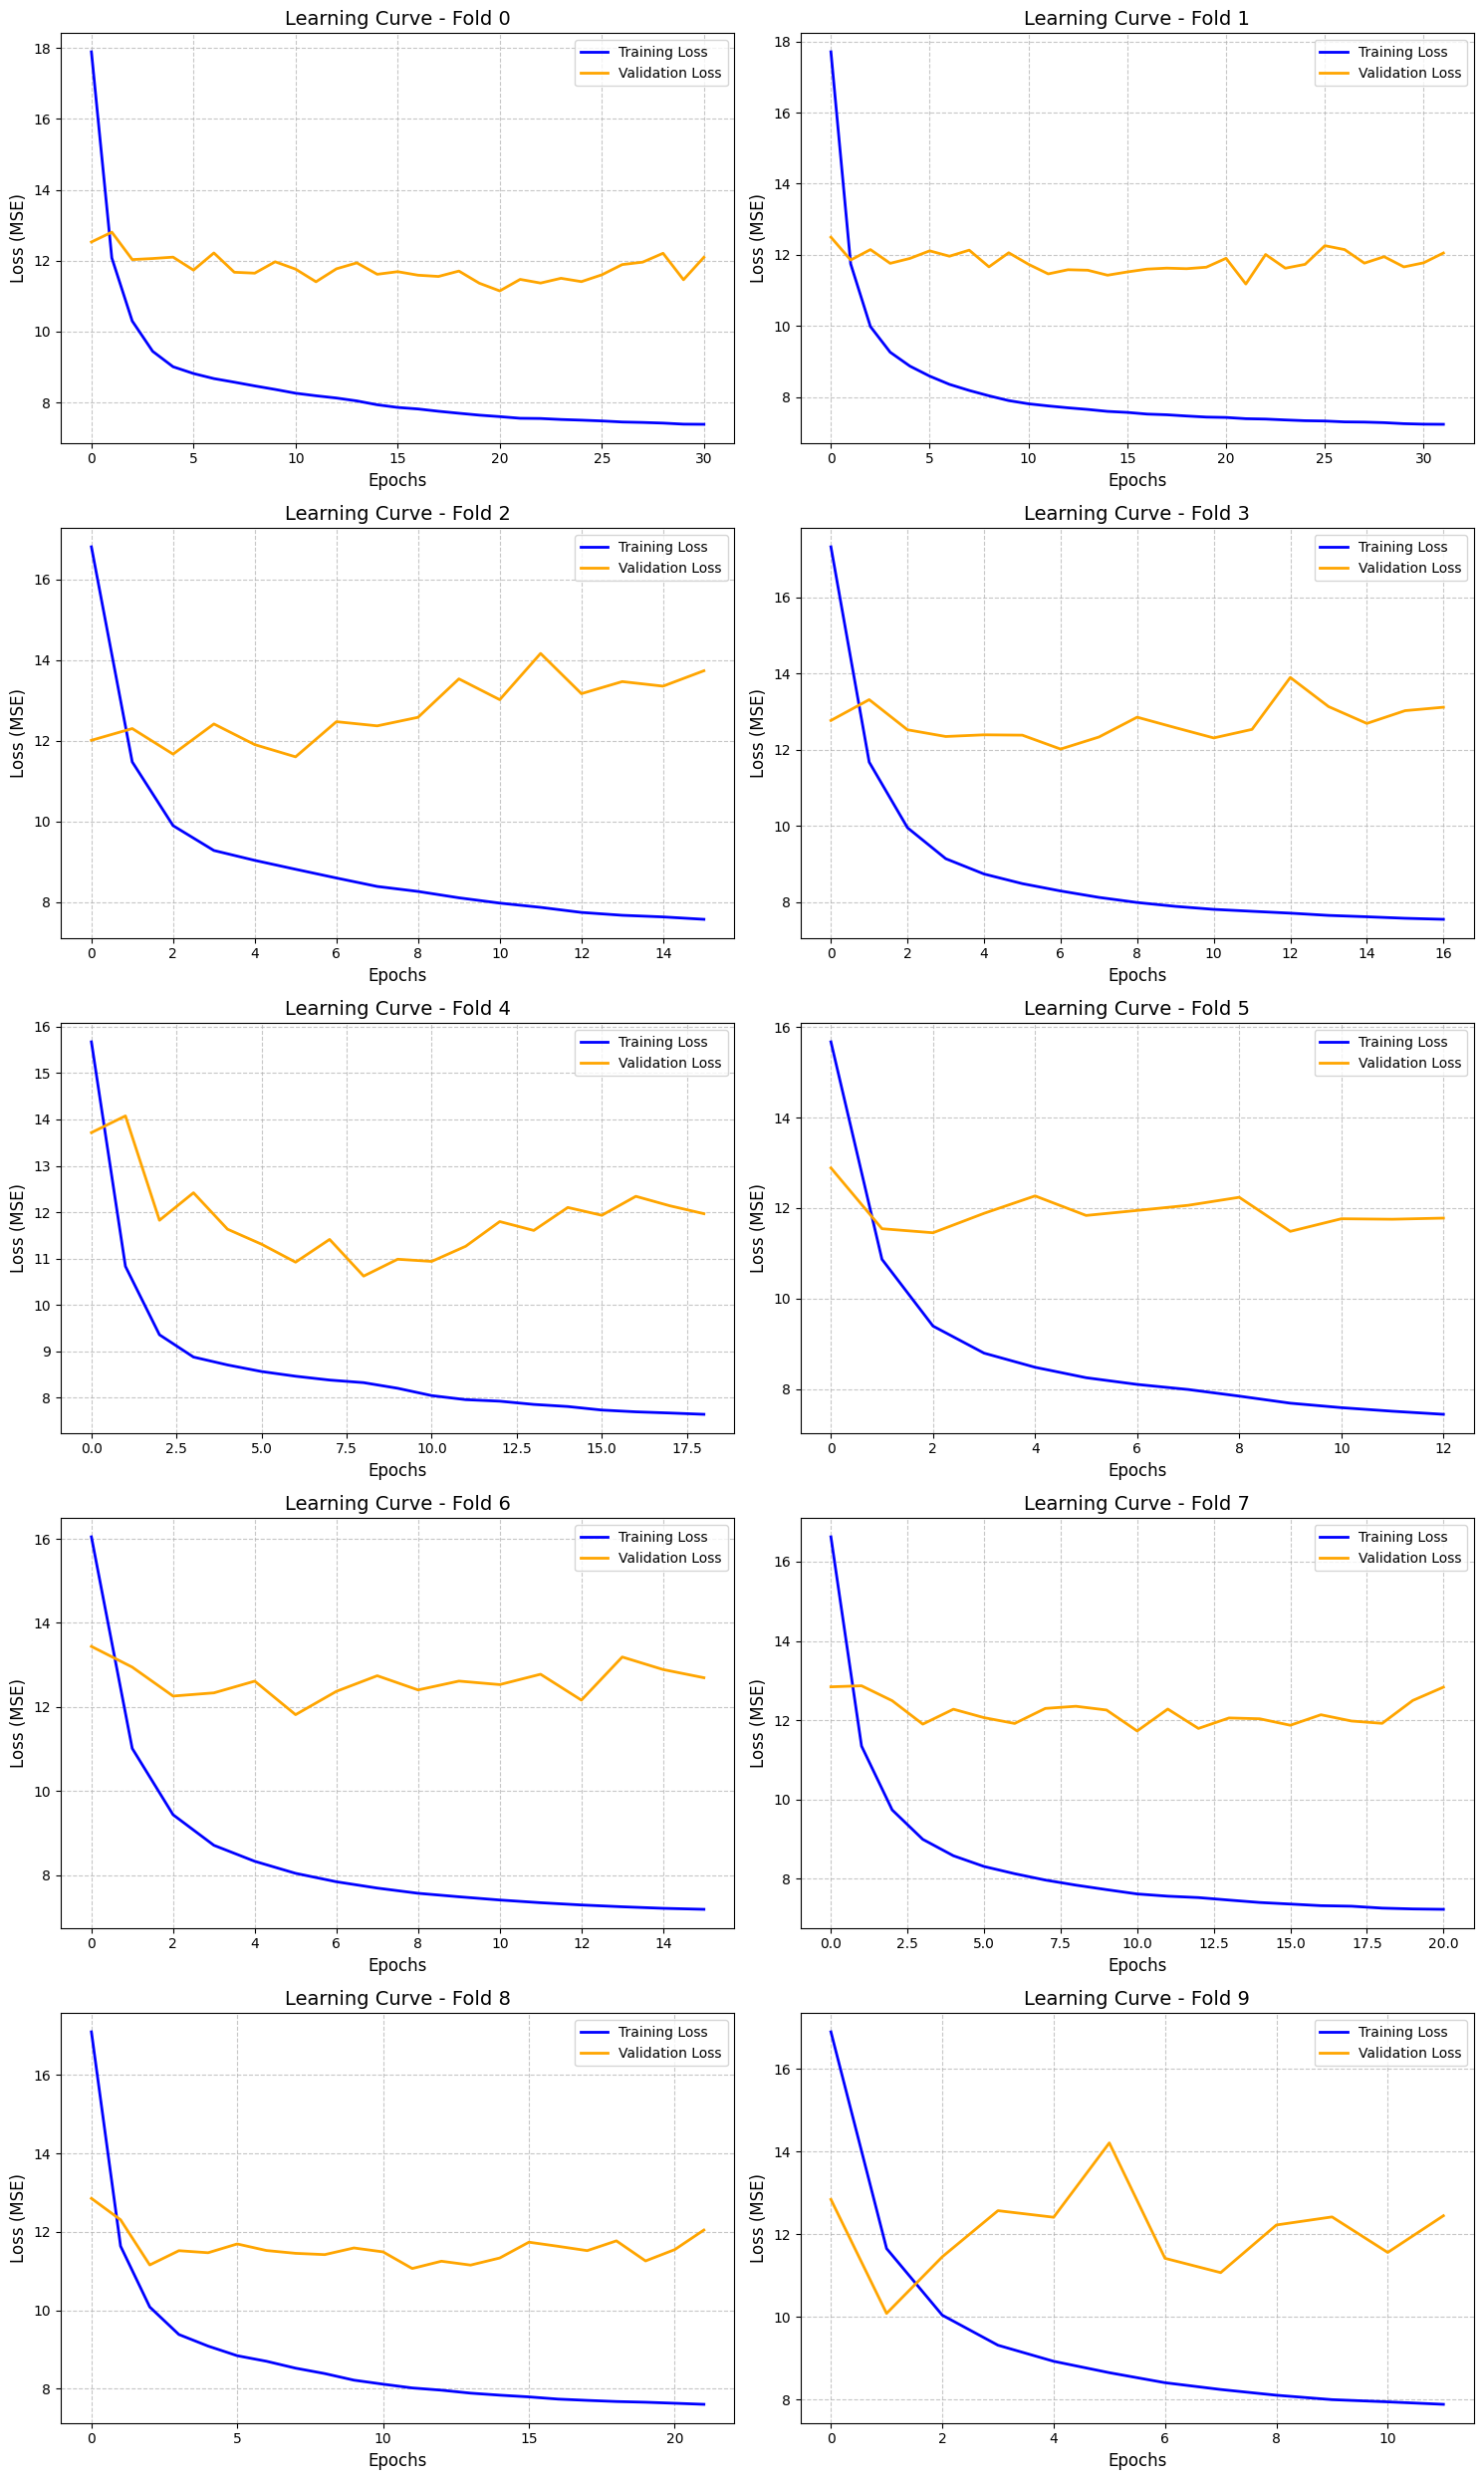

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_4_20260524_160239


In [16]:
k_fold_dict_4, save_dir_4 = pipeline(X_4, y_4, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_4")

## Comparison between solar flux and folds

--- Generazione Grafico: Flusso Solare vs Divisione Fold ---
Grafico salvato con successo in: plots/solar_flux_folds_overlay_20260723_135943 (.png e .pdf)


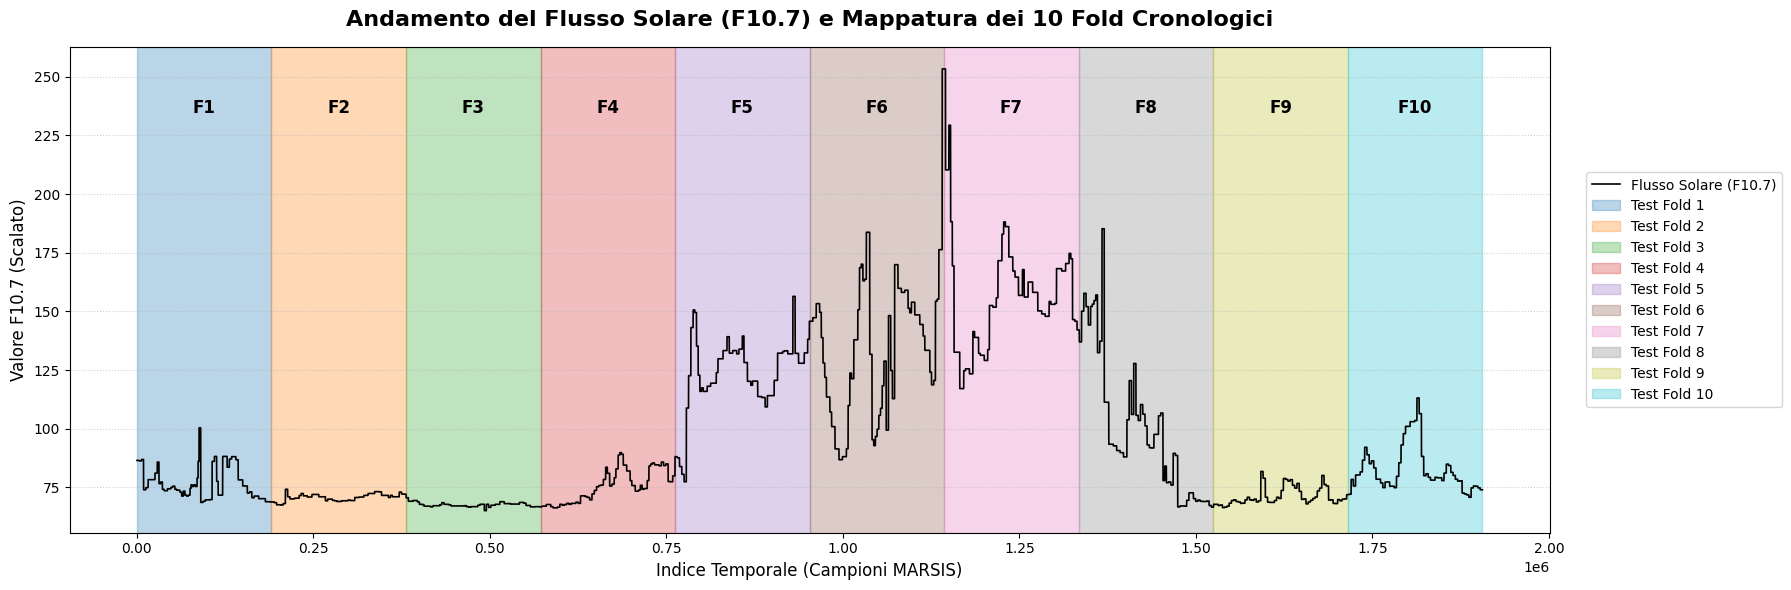

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold
from datetime import datetime
import os

print("--- Generazione Grafico: Flusso Solare vs Divisione Fold ---")

# Identificazione della colonna del Flusso Solare
target_feature = 'FM_data_F10_7_index'

if target_feature not in feature_names:
    raise ValueError(f"Feature '{target_feature}' non trovata nell'array feature_names.")

flux_idx = feature_names.index(target_feature)

# Estraiamo tutti i valori del flusso solare dalla matrice di addestramento
# Nota: Essendo estratti da X, i valori mostrati saranno quelli pre-processati/scalati
solar_flux_values = X[:, flux_idx]

# 2. Ricreazione esatta dei 10 Fold Cronologici usati nella pipeline
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=False) # shuffle=False mantiene l'ordine temporale

# 3. Configurazione della Figura
plt.figure(figsize=(18, 6))

# Disegniamo la linea continua del Flusso Solare in primo piano (zorder=2)
plt.plot(solar_flux_values, color='black', linewidth=1.2, label='Flusso Solare (F10.7)', zorder=2)

# 4. Creazione dell'overlay dei Fold
# Palette di colori per distinguere visivamente le 10 finestre di test
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

fold_idx = 1
for train_index, test_index in kf.split(X):
    # Troviamo l'inizio e la fine cronologica del Test Set per questo fold
    start_idx = test_index[0]
    end_idx = test_index[-1]
    
    # Aggiungiamo il rettangolo colorato di sfondo (zorder=1 per tenerlo dietro la linea)
    plt.axvspan(start_idx, end_idx, color=colors[(fold_idx-1) % len(colors)], 
                alpha=0.3, label=f'Test Fold {fold_idx}', zorder=1)
    
    # Aggiungiamo un'etichetta testuale in alto al centro di ogni fold
    mid_idx = (start_idx + end_idx) // 2
    plt.text(mid_idx, np.max(solar_flux_values) * 0.95, f'F{fold_idx}', 
             color='black', fontweight='bold', fontsize=12, ha='center', va='top', zorder=3)
    
    fold_idx += 1

# 5. Personalizzazione Grafica
plt.title('Andamento del Flusso Solare (F10.7) e Mappatura dei 10 Fold Cronologici', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Indice Temporale (Campioni MARSIS)', fontsize=12)
plt.ylabel('Valore F10.7 (Scalato)', fontsize=12)

# Griglia solo sull'asse Y per facilitare la lettura dei picchi
plt.grid(True, linestyle=':', alpha=0.6, axis='y')

# Spostiamo la legenda esternamente a destra per non coprire l'andamento della serie
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.tight_layout()

# 6. Salvataggio su disco (coerente con la struttura delle cartelle del progetto)
timestamp_plot = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path_plot = f"plots/solar_flux_folds_overlay_{timestamp_plot}"

plt.savefig(f"{save_path_plot}.png", dpi=600, bbox_inches='tight')
plt.savefig(f"{save_path_plot}.pdf", format='pdf', bbox_inches='tight')
print(f"Grafico salvato con successo in: {save_path_plot} (.png e .pdf)")

plt.show()